# **Auditoria de master db**

## *Carga de bd*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Opcional: para ver todas las columnas
pd.set_option("display.max_columns", 200)

# Ruta al dataset maestro
PATH_MASTER = "../data/grouped_data/MASTER_MULTITASK_V4_PLAN_A.csv"

# Cargar dataset
df = pd.read_csv(PATH_MASTER, low_memory=False)

print("Shape:", df.shape)
print("Columnas:", len(df.columns))
df.head()


Shape: (422526, 46)
Columnas: 46


,tbp_lv_x,isic_id,tbp_lv_C,tbp_lv_H,tbp_lv_location_simple,tbp_lv_areaMM2,tbp_lv_L,tbp_lv_deltaL,clin_size_long_diam_mm,tbp_lv_eccentricity,tbp_lv_Bext,tbp_lv_nevi_confidence,tbp_lv_color_std_mean,tbp_lv_z,head_B_label,tbp_lv_deltaLB,sex,tbp_lv_perimeterMM,tbp_lv_location,tbp_lv_area_perim_ratio,patient_id,tbp_lv_symm_2axis,lesion_id,tbp_lv_y,tbp_lv_Hext,tbp_lv_Lext,tbp_lv_norm_border,source_db,image_type,tbp_lv_minorAxisMM,tbp_lv_symm_2axis_angle,tbp_lv_radial_color_std_max,tbp_lv_stdLExt,tbp_lv_deltaB,age_approx,tbp_lv_Aext,tbp_lv_deltaA,tbp_lv_deltaLBnorm,anatom_site_general,tbp_lv_stdL,tbp_lv_norm_color,master_group_id,head_A_label,tbp_lv_B,tbp_lv_A,tbp_lv_Cext
0,-182.703552,ISIC_0015670,33.684638,53.058545,Right Leg,3.152561,54.367448,-7.658253,3.04,0.901302,23.954773,2.628592e-03,0.00000,-42.427948,0,8.360566,male,9.307003,Right Leg - Upper,27.476170,IP_1235828,0.590476,NaN,613.493652,55.828924,62.025701,7.091360,ISIC,TBP tile: close-up,1.543016,85.0,0.00000,2.637780,2.967674,60.0,16.261975,3.982447,5.784302,lower extremity,2.036195,0.000000,p_IP_1235828,0.0,26.922447,20.244422,28.953117
1,-0.078308,ISIC_0015845,41.219030,39.702910,Head & Neck,0.919497,48.861520,-6.500838,1.10,0.639885,24.549290,1.334303e-07,0.00000,57.174500,0,6.839008,male,3.354148,Head & Neck,12.235290,IP_8170065,0.285714,IL_6727506,1575.687000,44.064040,55.362360,2.116402,ISIC,TBP tile: close-up,0.821918,55.0,0.00000,3.912844,1.781713,60.0,25.364740,6.347830,4.987244,head/neck,0.853227,0.000000,p_IP_8170065,0.0,26.331000,31.712570,35.299260
2,123.649700,ISIC_0015864,44.174920,59.265850,Torso Back,3.265153,53.961180,-7.709336,3.40,0.932147,33.485410,2.959177e-04,0.00000,232.908900,0,9.092376,male,8.886309,Torso Back Top Third,24.184620,IP_6724798,0.361905,NaN,1472.010000,62.909730,61.670520,4.798335,ISIC,TBP tile: close-up,1.194905,105.0,0.00000,1.950777,4.485044,60.0,17.128170,5.447655,6.290359,posterior torso,1.743651,0.000000,p_IP_6724798,0.0,37.970460,22.575830,37.611800
3,-141.024780,ISIC_0015902,25.746200,56.414429,Torso Front,6.079940,18.649518,-4.665323,3.22,0.654458,21.121356,2.198945e+01,0.51452,58.359802,0,4.783413,male,9.514499,Torso Front Top Half,14.889242,IP_4111386,0.209581,NaN,1442.185791,60.060388,23.314841,1.975874,ISIC,TBP tile: close-up,2.481328,130.0,0.66469,1.573733,0.326788,65.0,12.164757,2.077572,6.400196,anterior torso,1.258541,1.771705,p_IP_4111386,0.0,21.448144,14.242329,24.374023
4,-72.315640,ISIC_0024200,36.217980,46.946070,Torso Front,2.101708,46.276310,-8.579431,2.73,0.946448,25.710460,1.378832e-03,0.00000,21.428960,0,9.148495,male,6.467562,Torso Front Top Half,19.902560,IP_8313778,0.313433,NaN,1488.720000,52.041180,54.855740,3.658854,ISIC,TBP tile: close-up,0.929916,20.0,0.00000,2.480509,0.754434,55.0,20.057470,4.668053,6.531302,anterior torso,2.085409,0.000000,p_IP_8313778,0.0,26.464900,24.725520,32.608740


## **1.1) Unicidad de identificadores y estructura de grupos**

## *1.1.1 – Comprobar unicidad de isic_id y resumen de master_group_id*

In [2]:
# Comprobar unicidad de isic_id
isic_unique = df["isic_id"].is_unique
num_dup_isic = df["isic_id"].duplicated().sum()

print("¿isic_id es único?:", isic_unique)
print("Número de isic_id duplicados:", num_dup_isic)

# Resumen de master_group_id
print("\nResumen de master_group_id (nº de imágenes por grupo):")
group_sizes = df["master_group_id"].value_counts()
print(group_sizes.describe())

# Ejemplo de los grupos con más imágenes
print("\nTop 10 grupos con más imágenes:")
print(group_sizes.head(10))


¿isic_id es único?: True
Número de isic_id duplicados: 0

Resumen de master_group_id (nº de imágenes por grupo):
count    11895.000000
mean        35.521311
std        193.085321
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       9184.000000
Name: count, dtype: float64

Top 10 grupos con más imágenes:
master_group_id
p_IP_1117889    9184
p_IP_5714646    6267
p_IP_3921915    5568
p_IP_7797815    4454
p_IP_9577633    3583
p_IP_5539318    2859
p_IP_9853536    2327
p_IP_5143034    2283
p_IP_0321326    2245
p_IP_5426188    2193
Name: count, dtype: int64


## *1.1.2 – Distribución de imágenes por grupo (histograma)*

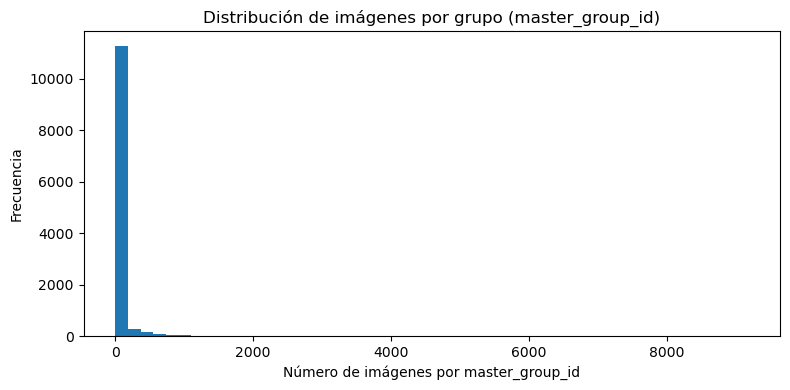

In [3]:
plt.figure(figsize=(8, 4))
plt.hist(group_sizes.values, bins=50)
plt.xlabel("Número de imágenes por master_group_id")
plt.ylabel("Frecuencia")
plt.title("Distribución de imágenes por grupo (master_group_id)")
plt.tight_layout()
plt.show()


## *1.1.3 – Imágenes por patient_id y lesion_id*

In [4]:
# Cuidado con NaNs: los ignoramos en el conteo
if "patient_id" in df.columns:
    imgs_per_patient = df.dropna(subset=["patient_id"]).groupby("patient_id")["isic_id"].nunique()
    print("Resumen imágenes por patient_id:")
    print(imgs_per_patient.describe())
else:
    print("Columna patient_id no encontrada en df.columns")

if "lesion_id" in df.columns:
    imgs_per_lesion = df.dropna(subset=["lesion_id"]).groupby("lesion_id")["isic_id"].nunique()
    print("\nResumen imágenes por lesion_id:")
    print(imgs_per_lesion.describe())
else:
    print("Columna lesion_id no encontrada en df.columns")


Resumen imágenes por patient_id:
count    3113.000000
mean      130.373273
std       360.954043
min         1.000000
25%         1.000000
50%         3.000000
75%       117.000000
max      9184.000000
Name: isic_id, dtype: float64

Resumen imágenes por lesion_id:
count    31467.000000
mean         1.261258
std          1.212097
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         39.000000
Name: isic_id, dtype: float64


## **1.2) Duplicados físicos y lógicos**

## *1.2.1 – Duplicados por isic_id (filas exactas y por ID)*

In [5]:
# Duplicados por isic_id
dup_isic_mask = df["isic_id"].duplicated(keep=False)
num_dup_isic = dup_isic_mask.sum()
print("Nº de filas con isic_id duplicado:", num_dup_isic)

if num_dup_isic > 0:
    print("\nEjemplo de isic_id duplicados:")
    display(df[dup_isic_mask].sort_values("isic_id").head(10))

# Filas completamente duplicadas (todas las columnas iguales)
num_full_dups = df.duplicated().sum()
print("\nNº de filas completamente duplicadas:", num_full_dups)


Nº de filas con isic_id duplicado: 0

Nº de filas completamente duplicadas: 0


## *1.2.2 – Duplicados “lógicos” por combinación de claves clínicas*

>agrupar por claves como (patient_id, lesion_id, anatom_site_general, image_type, tbp_lv_x, tbp_lv_y, tbp_lv_z, tbp_lv_areaMM2, tbp_lv_perimeterMM).

In [6]:
dup_key_cols = [
    "patient_id",
    "lesion_id",
    "anatom_site_general",
    "image_type",
    "tbp_lv_x",
    "tbp_lv_y",
    "tbp_lv_z",
    "tbp_lv_areaMM2",
    "tbp_lv_perimeterMM",
]

# Nos quedamos solo con las columnas que existen realmente
dup_key_cols = [c for c in dup_key_cols if c in df.columns]
print("Columnas usadas para duplicados lógicos:", dup_key_cols)

# Creamos una clave combinada
dup_keys = df[dup_key_cols].astype(str).agg("__".join, axis=1)

# Marcamos claves que aparecen más de una vez
value_counts = dup_keys.value_counts()
multi_mask = dup_keys.isin(value_counts[value_counts > 1].index)
num_multi = multi_mask.sum()

print("Nº de filas que comparten exactamente las mismas claves lógicas:", num_multi)

if num_multi > 0:
    print("\nEjemplo de grupos de posibles duplicados lógicos:")
    display(df.loc[multi_mask, dup_key_cols + ["isic_id"]].head(30))


Columnas usadas para duplicados lógicos: ['patient_id', 'lesion_id', 'anatom_site_general', 'image_type', 'tbp_lv_x', 'tbp_lv_y', 'tbp_lv_z', 'tbp_lv_areaMM2', 'tbp_lv_perimeterMM']
Nº de filas que comparten exactamente las mismas claves lógicas: 14606

Ejemplo de grupos de posibles duplicados lógicos:


,patient_id,lesion_id,anatom_site_general,image_type,tbp_lv_x,tbp_lv_y,tbp_lv_z,tbp_lv_areaMM2,tbp_lv_perimeterMM,isic_id
401059,NaN,NaN,upper extremity,dermoscopic,-1.0,-1.0,-1.0,-1.0,-1.0,ISIC_0000002
401060,NaN,NaN,posterior torso,dermoscopic,-1.0,-1.0,-1.0,-1.0,-1.0,ISIC_0000004
401061,NaN,NaN,posterior torso,dermoscopic,-1.0,-1.0,-1.0,-1.0,-1.0,ISIC_0000013
401062,NaN,NaN,lower extremity,dermoscopic,-1.0,-1.0,-1.0,-1.0,-1.0,ISIC_0000022
401063,NaN,NaN,lower extremity,dermoscopic,-1.0,-1.0,-1.0,-1.0,-1.0,ISIC_0000026
401064,NaN,NaN,posterior torso,dermoscopic,-1.0,-1.0,-1.0,-1.0,-1.0,ISIC_0000029
401065,NaN,NaN,lower extremity,dermoscopic,-1.0,-1.0,-1.0,-1.0,-1.0,ISIC_0000030
401066,NaN,NaN,upper extremity,dermoscopic,-1.0,-1.0,-1.0,-1.0,-1.0,ISIC_0000031
401067,NaN,NaN,lower extremity,dermoscopic,-1.0,-1.0,-1.0,-1.0,-1.0,ISIC_0000035
401068,NaN,NaN,upper extremity,dermoscopic,-1.0,-1.0,-1.0,-1.0,-1.0,ISIC_0000036


> De estos valores ninguno son duplicados lógicos, solo que al tener los mismos valores imputados los confunde, pero tienen id_ISIC diferentes

## *1.2.3 – (Opcional) Duplicados físicos por imagen (hash de fichero)*

In [ ]:
import os
import hashlib

IMAGES_DIR = "../images_ISIC" 

def file_hash(path, block_size=65536):
    hasher = hashlib.md5()
    with open(path, "rb") as f:
        buf = f.read(block_size)
        while buf:
            hasher.update(buf)
            buf = f.read(block_size)
    return hasher.hexdigest()

# EJEMPLO: calcular hash de las primeras N imágenes de df
N = 10000  # puedes cambiar esto o recorrer todas si quieres
hashes = {}

for idx, row in df.head(N).iterrows():
    img_id = row["isic_id"]
    # Ejemplo de nombre de fichero típico: ISIC_XXXXX.jpg
    fname_jpg = os.path.join(IMAGES_DIR, f"{img_id}.jpg")
    fname_png = os.path.join(IMAGES_DIR, f"{img_id}.png")
    
    if os.path.exists(fname_jpg):
        path = fname_jpg
    elif os.path.exists(fname_png):
        path = fname_png
    else:
        continue
    
    h = file_hash(path)
    hashes.setdefault(h, []).append(img_id)

# Mostrar hashes con más de una imagen asociada (duplicados físicos)
dup_physical = {h: ids for h, ids in hashes.items() if len(ids) > 1}
print("Nº de grupos de duplicados físicos encontrados (entre las primeras N imágenes):", len(dup_physical))
list(dup_physical.items())[:5]


Nº de grupos de duplicados físicos encontrados (entre las primeras N imágenes): 0


[]

## **1.3) Análisis de valores faltantes (NaNs)**

## *1.3.1 – Porcentaje de NaNs por columna*

In [13]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_table = missing_pct.to_frame(name="%_missing")

print("Porcentaje de valores faltantes por columna:")
display(missing_table)

# Guardar tabla si quieres
# missing_table.to_csv("../data/analysis/missing_values_master.csv")


Porcentaje de valores faltantes por columna:


,%_missing
lesion_id,90.606969
patient_id,3.946266
tbp_lv_C,0.000000
tbp_lv_H,0.000000
tbp_lv_x,0.000000
isic_id,0.000000
tbp_lv_L,0.000000
tbp_lv_deltaL,0.000000
clin_size_long_diam_mm,0.000000
tbp_lv_eccentricity,0.000000


>Aunque patient_id y lesion_id presentan valores faltantes (≈4% y ≈91% respectivamente), esto no afecta al control de fugas de datos porque se ha definido un identificador sintético de grupo, master_group_id, con cobertura del 100%.

master_group_id se construye jerárquicamente a partir de patient_id, lesion_id e isic_id, de modo que:

- Si hay patient_id, agrupa por paciente.

- Si solo hay lesion_id, agrupa por lesión.

- Si no hay ninguno de los dos, cada imagen se considera su propio grupo.

>Este identificador se utiliza como columna de agrupación en StratifiedGroupKFold para evitar fugas de información entre train, val y test, incluso cuando falten IDs originales en los metadatos.

## *1.3.2 – Gráfico de barras de % de NaNs (para las peores columnas)*

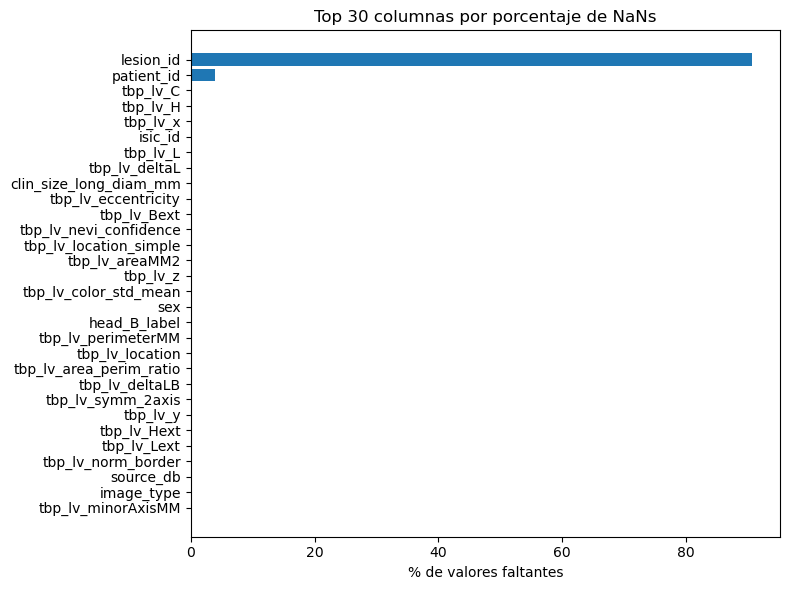

In [14]:
top_n = 30  # mostrar las 30 columnas con más NaNs
plt.figure(figsize=(8, 6))
plt.barh(missing_pct.index[:top_n], missing_pct.values[:top_n])
plt.xlabel("% de valores faltantes")
plt.title(f"Top {top_n} columnas por porcentaje de NaNs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## **1.4) Presencia de columnas tbp_lv_^ en ambas fuentes (ISIC vs MALIGNANT)**

In [ ]:
if "source_db" in df.columns:
    print(df["source_db"].value_counts())
    
    # Columnas tbp_lv_*
    tbp_cols = [c for c in df.columns if c.startswith("tbp_lv_")]
    print("\nNúmero de columnas tbp_lv_*:", len(tbp_cols))
    print("Ejemplo de columnas tbp_lv_*:", tbp_cols[:15])
    
    # Porcentaje de NaNs en tbp_lv_* por fuente
    tbp_missing_by_source = {}
    for src in df["source_db"].unique():
        subset = df[df["source_db"] == src]
        tbp_missing_by_source[src] = subset[tbp_cols].isna().mean().mean() * 100
    print("\nPorcentaje medio de NaNs en tbp_lv_* por source_db:")
    for src, pct in tbp_missing_by_source.items():
        print(f"  {src}: {pct:.2f}%")
else:
    print("No se encontró la columna source_db en el dataset.")


source_db
ISIC         401059
MALIGNANT     21467
Name: count, dtype: int64

Número de columnas tbp_lv_*: 34
Ejemplo de columnas tbp_lv_*: ['tbp_lv_x', 'tbp_lv_C', 'tbp_lv_H', 'tbp_lv_location_simple', 'tbp_lv_areaMM2', 'tbp_lv_L', 'tbp_lv_deltaL', 'tbp_lv_eccentricity', 'tbp_lv_Bext', 'tbp_lv_nevi_confidence', 'tbp_lv_color_std_mean', 'tbp_lv_z', 'tbp_lv_deltaLB', 'tbp_lv_perimeterMM', 'tbp_lv_location']

Porcentaje medio de NaNs en tbp_lv_* por source_db:
  ISIC: 0.00%
  MALIGNANT: 0.00%


>No hay valores NaN, eso significa que la imputacion esta bien hecha

## **1.5) Distribución de clases y etiquetas (Head A / Head B)**

## *1.5.1 – Distribución global de Head A y Head B*

In [16]:
def distribución_clases(y):
    vals, counts = np.unique(y, return_counts=True)
    total = counts.sum()
    return {int(v): f"{c} ({c/total*100:.2f}%)" for v, c in zip(vals, counts)}

print("Distribución Head A (global):")
print(distribución_clases(df["head_A_label"].values))

print("\nDistribución Head B (global):")
print(distribución_clases(df["head_B_label"].values))


Distribución Head A (global):
{0: '400666 (94.83%)', 1: '21860 (5.17%)'}

Distribución Head B (global):
{0: '400666 (94.83%)', 1: '10628 (2.52%)', 2: '8759 (2.07%)', 3: '2473 (0.59%)'}


## *1.5.2 – Distribución por fuente de datos (source_db)*

In [17]:
if "source_db" in df.columns:
    print("\nHead A por source_db:")
    for src, sub in df.groupby("source_db"):
        print(f"\nFuente: {src}")
        print(distribución_clases(sub["head_A_label"].values))
    
    print("\nHead B por source_db:")
    for src, sub in df.groupby("source_db"):
        print(f"\nFuente: {src}")
        print(distribución_clases(sub["head_B_label"].values))
else:
    print("Columna source_db no encontrada.")



Head A por source_db:

Fuente: ISIC
{0: '400666 (99.90%)', 1: '393 (0.10%)'}

Fuente: MALIGNANT
{1: '21467 (100.00%)'}

Head B por source_db:

Fuente: ISIC
{0: '400666 (99.90%)', 1: '157 (0.04%)', 2: '163 (0.04%)', 3: '73 (0.02%)'}

Fuente: MALIGNANT
{1: '10471 (48.78%)', 2: '8596 (40.04%)', 3: '2400 (11.18%)'}


## *1.5.3 – Coherencia Head A vs Head B*

> Ejemplo: que no haya head_A=0 (benigno) con clases claramente malignas en Head B.

In [18]:
# Definimos qué consideramos clases malignas en Head B
malignas_headB = [2, 3]  # MEL, BCC; (añadir 4 si la tuvieras aún en esta versión)

mask_incoh = (df["head_A_label"] == 0) & (df["head_B_label"].isin(malignas_headB))
num_incoh = mask_incoh.sum()
print("Nº de filas con Head_A=0 (benigno) pero Head_B maligno:", num_incoh)

if num_incoh > 0:
    display(df.loc[mask_incoh, ["isic_id", "head_A_label", "head_B_label"]].head(20))


Nº de filas con Head_A=0 (benigno) pero Head_B maligno: 0


## *1.5.4 – (Opcional) Tabla de contingencia con diagnósticos originales*

In [19]:
diag_cols = [c for c in ["iddx_3", "diagnosis_3"] if c in df.columns]
print("Columnas de diagnóstico originales encontradas:", diag_cols)

if diag_cols:
    diag_col = diag_cols[0]  # elegimos una
    print(f"\nTabla de contingencia entre {diag_col} y Head B:")
    tabla = pd.crosstab(df[diag_col], df["head_B_label"])
    display(tabla)
else:
    print("No hay columnas de diagnóstico originales en el MASTER (se habrán usado antes en el pipeline).")


Columnas de diagnóstico originales encontradas: []
No hay columnas de diagnóstico originales en el MASTER (se habrán usado antes en el pipeline).


In [20]:
diag_cols = [c for c in ["iddx_3", "diagnosis_3"] if c in df.columns]
print("Columnas de diagnóstico originales encontradas:", diag_cols)

if diag_cols:
    diag_col = diag_cols[0]  # elegimos una
    print(f"\nTabla de contingencia entre {diag_col} y Head B:")
    tabla = pd.crosstab(df[diag_col], df["head_B_label"])
    display(tabla)
else:
    print("No hay columnas de diagnóstico originales en el MASTER (se habrán usado antes en el pipeline).")


Columnas de diagnóstico originales encontradas: []
No hay columnas de diagnóstico originales en el MASTER (se habrán usado antes en el pipeline).


## **1.6) Tablas y gráficas recomendadas para el TFG**

## *1.6.1 – Tabla de nº de imágenes, pacientes y lesiones únicos*

In [21]:
num_imgs = df["isic_id"].nunique()
num_patients = df["patient_id"].nunique() if "patient_id" in df.columns else None
num_lesions = df["lesion_id"].nunique() if "lesion_id" in df.columns else None

print("Resumen de entidades:")
print("  Imágenes únicas:", num_imgs)
print("  Pacientes únicos:", num_patients)
print("  Lesiones únicas:", num_lesions)


Resumen de entidades:
  Imágenes únicas: 422526
  Pacientes únicos: 3113
  Lesiones únicas: 31467


## *1.6.2 – Histograma de edad global y por clase (si tienes age_approx)*

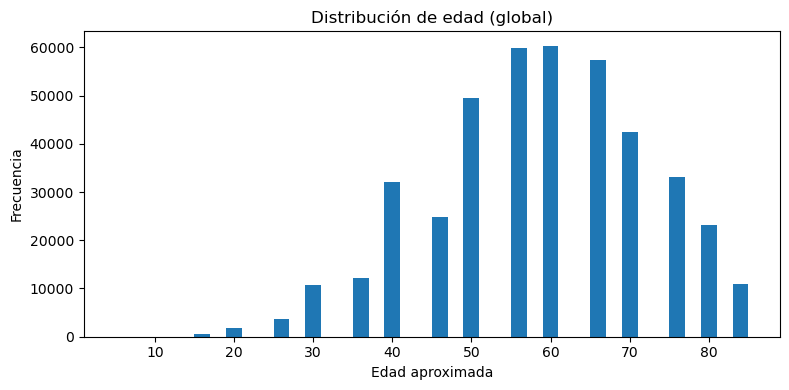

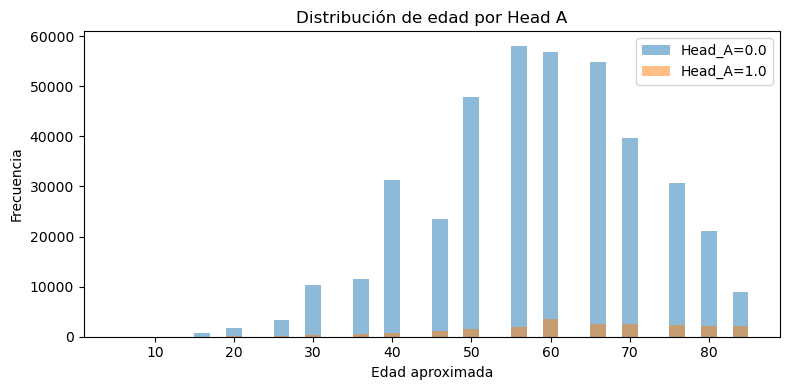

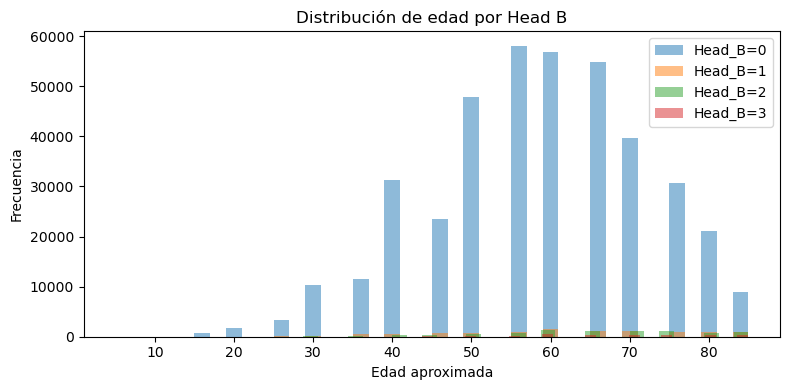

In [25]:
if "age_approx" in df.columns:
    plt.figure(figsize=(8, 4))
    plt.hist(df["age_approx"].dropna(), bins=40)
    plt.xlabel("Edad aproximada")
    plt.ylabel("Frecuencia")
    plt.title("Distribución de edad (global)")
    plt.tight_layout()
    plt.show()
    
    # Edad por Head A
    plt.figure(figsize=(8, 4))
    for label in sorted(df["head_A_label"].unique()):
        subset = df[df["head_A_label"] == label]["age_approx"].dropna()
        plt.hist(subset, bins=40, alpha=0.5, label=f"Head_A={label}")
    plt.xlabel("Edad aproximada")
    plt.ylabel("Frecuencia")
    plt.title("Distribución de edad por Head A")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Edad por Head B
    plt.figure(figsize=(8, 4))
    for label in sorted(df["head_B_label"].unique()):
        subset = df[df["head_B_label"] == label]["age_approx"].dropna()
        plt.hist(subset, bins=40, alpha=0.5, label=f"Head_B={label}")
    plt.xlabel("Edad aproximada")
    plt.ylabel("Frecuencia")
    plt.title("Distribución de edad por Head B")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Columna age_approx no encontrada.")


## *1.6.3 – Distribución de clases por fuente (source_db)*

Head A (% por fuente):


head_A_label,0.0,1.0
source_db,,
ISIC,99.902009,0.097991
MALIGNANT,0.000000,100.000000



Head B (% por fuente):


head_B_label,0,1,2,3
source_db,,,,
ISIC,99.902009,0.039146,0.040642,0.018202
MALIGNANT,0.000000,48.777193,40.042856,11.179951


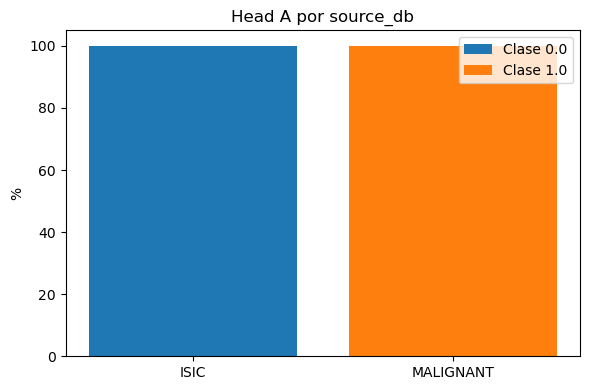

In [26]:
if "source_db" in df.columns:
    headA_by_source = pd.crosstab(df["source_db"], df["head_A_label"], normalize="index") * 100
    headB_by_source = pd.crosstab(df["source_db"], df["head_B_label"], normalize="index") * 100
    
    print("Head A (% por fuente):")
    display(headA_by_source)
    
    print("\nHead B (% por fuente):")
    display(headB_by_source)
    
    # Gráfico de barras apiladas para Head A
    plt.figure(figsize=(6, 4))
    bottom = np.zeros(len(headA_by_source))
    for cls in headA_by_source.columns:
        vals = headA_by_source[cls].values
        plt.bar(headA_by_source.index, vals, bottom=bottom, label=f"Clase {cls}")
        bottom += vals
    plt.ylabel("%")
    plt.title("Head A por source_db")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Columna source_db no encontrada.")


## **2) Gestión de etiquetas y definición de tareas**

## *2.1) Mapeo diagnóstico → clase (Head A y Head B)*

### *2.1.1) distribución de Head A y Head B*

=== DISTRIBUCIÓN HEAD_A_LABEL ===


,clase,n,%
0,0.0,400666,94.83
1,1.0,21860,5.17


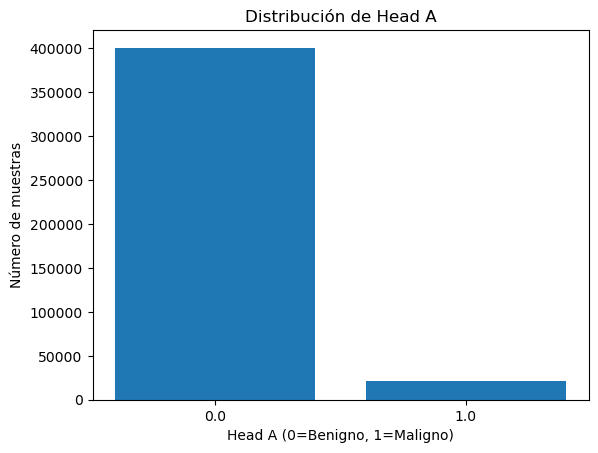


=== DISTRIBUCIÓN HEAD_B_LABEL ===


,clase,label,n,%
0,NV,0,400666,94.83
1,O-BEN,1,10628,2.52
2,MEL,2,8759,2.07
3,BCC,3,2473,0.59


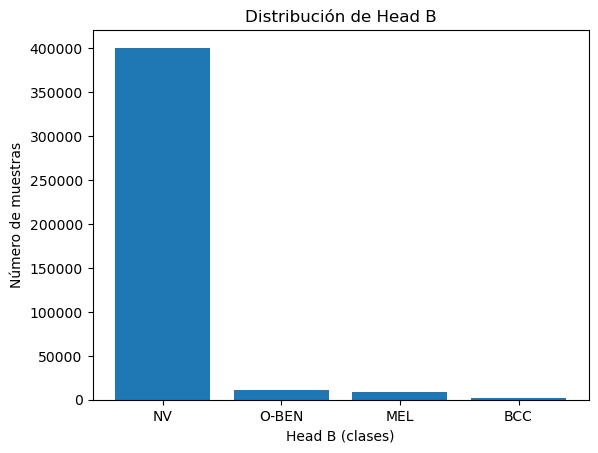

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Distribución Head A ---
print("=== DISTRIBUCIÓN HEAD_A_LABEL ===")
headA_counts = df["head_A_label"].value_counts().sort_index()
headA_props  = (headA_counts / len(df) * 100).round(2)

display(pd.DataFrame({
    "clase": headA_counts.index,
    "n": headA_counts.values,
    "%": headA_props.values
}))

# Gráfico de barras
plt.figure()
plt.bar(headA_counts.index.astype(str), headA_counts.values)
plt.xlabel("Head A (0=Benigno, 1=Maligno)")
plt.ylabel("Número de muestras")
plt.title("Distribución de Head A")
plt.show()

# --- Distribución Head B ---
print("\n=== DISTRIBUCIÓN HEAD_B_LABEL ===")
headB_counts = df["head_B_label"].value_counts().sort_index()
headB_props  = (headB_counts / len(df) * 100).round(2)

# nombres amigables según tu mapeo
headB_names = {
    0: "NV",
    1: "O-BEN",
    2: "MEL",
    3: "BCC",
    4: "SCC+"
}

headB_table = pd.DataFrame({
    "clase": headB_counts.index.map(headB_names),
    "label": headB_counts.index,
    "n": headB_counts.values,
    "%": headB_props.values
})
display(headB_table)

# Gráfico de barras para Head B
plt.figure()
plt.bar(headB_table["clase"], headB_table["n"])
plt.xlabel("Head B (clases)")
plt.ylabel("Número de muestras")
plt.title("Distribución de Head B")
plt.show()


## *2.2) Coherencia binario vs multiclase*

In [35]:
# --- 1) Definir qué valores de Head B consideramos "malignos" en ESTE dataset ---

# En MASTER_MULTITASK_V4_PLAN_A:
# head_B_label = 0 → BENIGNO
# head_B_label = 1, 2, 3 → MALIGNO
is_malignant_B = df["head_B_label"] != 0

# Máscara "es maligno" según Head A
is_malignant_A = (df["head_A_label"] == 1)

# --- 2) Comprobación de equivalencia completa ---

mismatch_mask = (is_malignant_B != is_malignant_A)
num_mismatches = mismatch_mask.sum()
print(f"Nº de filas con incoherencia HeadA/HeadB: {num_mismatches}")

if num_mismatches > 0:
    print("\nEjemplos de inconsistencias:")
    display(df.loc[mismatch_mask, ["isic_id", "head_A_label", "head_B_label"]].head(20))

# Si quieres que falle duro si hay algún problema:
assert num_mismatches == 0, "Hay incoherencias entre Head A y Head B"


Nº de filas con incoherencia HeadA/HeadB: 0


## *2.3)Peso de las tareas (MTL)*

### Opciones para asignar los pesos a las clases

- a) Pesos fijos manuales (lo que tú propones: Loss_total = 1.2·L_A + 1.0·L_B)
- b) Pesos iguales (α = β = 1)
- c) Pesos automáticos tipo “Uncertainty Weighting”
- d) Pesos dinámicos tipo GradNorm u otros métodos de balance de gradientes

## *2.4) Agrupación de subclases raras*

In [ ]:
# Ya calculamos antes headB_table, pero aquí lo enfocamos a "rareza"
headB_counts = df["head_B_label"].value_counts().sort_index()
headB_props  = (headB_counts / len(df) * 100)

headB_names = {
    0: "NV",
    1: "O-BEN",
    2: "MEL",
    3: "BCC",
    4: "SCC+"
}

summary_B = pd.DataFrame({
    "label": headB_counts.index,
    "clase": headB_counts.index.map(headB_names),
    "n": headB_counts.values,
    "%": headB_props.round(4).values
})

# definimos minoritaria como <1% (puedes cambiar el umbral)
summary_B["es_minoritaria_<1%"] = summary_B["%"] < 1.0

display(summary_B)

,label,clase,n,%,es_minoritaria_<1%
0,0,NV,400666,94.8264,False
1,1,O-BEN,10628,2.5153,False
2,2,MEL,8759,2.0730,False
3,3,BCC,2473,0.5853,True


> En principio, aun que la clase 3 sea muy minoritaria, voy a intentar dejarla a ver si funciona.

## *2.5) Definición de métricas por tarea (y cómo calcularlas luego)*

### 2.5.1. Métricas interesantes que podrías calcular

#### 2.5.1.1. Para Head A (binaria BEN vs MAL, muy desbalanceada)

**Métricas básicas:**
- Accuracy (exactitud)
- Precision (PPV) de la clase MAL
- Recall / Sensibilidad de la clase MAL
- Especificidad (recall de la clase BEN)
- F1-score de MAL
- F1-score macro (media entre BEN y MAL)

**Métricas de área bajo curva (umbral-independientes):**
- AUC-ROC (Área bajo la curva ROC)
- AUC-PR (Área bajo la curva Precision–Recall, especialmente relevante con desbalanceo fuerte)

**Métricas de “equilibrio entre clases”:**
- Balanced Accuracy = (sensibilidad + especificidad) / 2
- Matthews Correlation Coefficient (MCC)

**Calibración de probabilidad (si usas probabilidades como salida):**
- Brier Score
- Curva de calibración / reliability diagram
- Expected Calibration Error (ECE) (más avanzado, opcional)

---

#### 2.5.1.2. Para Head B (multiclase NV / O-BEN / MEL / BCC / SCC+, muy desbalanceado)

**Globales:**
- Accuracy global
- Balanced Accuracy (media del recall de todas las clases)
- Top-k accuracy (p.ej. top-2 o top-3, opcional)

**F1 y recalls:**
- F1-macro (media simple del F1 de cada clase → trata igual a NV y O-BEN)
- F1-weighted (media ponderada por nº de ejemplos de cada clase)
- F1 por clase (F1_NV, F1_OBEN, F1_MEL, F1_BCC, F1_SCC+)
- Recall por clase (sensibilidad de MEL, BCC, SCC+…)
- Precision por clase, si quieres analizar dónde hay muchos falsos positivos

**Curvas y áreas:**
- ROC-AUC one-vs-rest por clase (ej. AUC para MEL vs resto, SCC+ vs resto, etc.)
- PR-AUC por clase (más útil para MEL y SCC+)

**Otras:**
- Matriz de confusión (muy importante para interpretar errores)
- Cohen’s Kappa (acuerdo corregido por azar, opcional)

**Calibración (si trabajas con probabilidades multiclase):**
- Brier score multiclase
- Curvas de calibración por clase (más avanzado / opcional)

---

## 2.5.2. ¿Qué te recomiendo calcular realmente?

### 2.5.2.1. Para Head A (screening BEN vs MAL)

**Yo tendría en el cuaderno, como mínimo:**

**Obligatorias (las que usaría sí o sí):**
- AUC-ROC
- Recall (sensibilidad) de la clase MAL
- F1-score de la clase MAL
- Accuracy (solo para que se vea lo engañosa que puede ser)

**Muy recomendables:**
- AUC-PR (porque la clase MAL es minoritaria)
- Balanced Accuracy
- Especificidad (para ver cuánto sacrificas de BEN al ganar sensibilidad)

**Opcionales / nice-to-have:**
- MCC
- Curva ROC y curva PR dibujadas
- Alguna métrica de calibración (Brier score)

---

### 2.5.2.2. Para Head B (diagnóstico diferencial multiclase)

**Obligatorias:**
- Accuracy global (aunque sea engañosa, es la que todo el mundo mira primero)
- Balanced Accuracy
- F1-macro
- F1 por clase (al menos para MEL, BCC, SCC+)

**Muy recomendables:**
- Matriz de confusión
- Recall por clase (MEL, BCC, SCC+ sobre todo)
- F1-weighted

**Opcionales / avanzadas:**
- ROC-AUC one-vs-rest para MEL y SCC+
- PR-AUC para MEL y SCC+
- Kappa, calibración, etc.

---

## 2.5.3. De todo eso, ¿qué “manda” para tu TFG?

### 👉 Head A (BEN vs MAL, screening)

**Métricas PRINCIPALES (las que mandan):**
- **AUC-ROC** → calidad global del score del modelo para separar BEN vs MAL.
- **Recall de la clase MAL** → cuántos melanomas/cánceres pillas (sensibilidad).

**Métricas SECUNDARIAS (para contexto, tablas, discusión):**
- **F1 de MAL** → equilibrio precisión–recall en la clase crítica.
- **Accuracy** → que se verá alta por el desbalanceo, la enseñas pero explicas sus limitaciones.
- **Balanced Accuracy** → útil para resumir sensibilidad y especificidad en una sola cifra.
- **(Opcional) AUC-PR** para hablar de comportamiento en clase minoritaria.

> “Para Head A consideramos **AUC-ROC** y **sensibilidad de la clase maligna** como métricas principales de rendimiento, dado el objetivo clínico de maximizar la detección de lesiones malignas. F1-score de la clase maligna, balanced accuracy y accuracy global se reportan como métricas de apoyo.”

---

### 👉 Head B (multiclase NV / O-BEN / MEL / BCC / SCC+)

**Métricas PRINCIPALES (las que mandan):**
- **Balanced Accuracy** → mide cuánto de bien aciertas de media en todas las clases, aunque estén desbalanceadas.
- **F1-macro** → pondera igual a NV que a SCC+, importante en un contexto clínico con clases minoritarias.

**Métricas SECUNDARIAS (análisis fino):**
- **Accuracy global** → para que el lector tenga una referencia “clásica”.
- **F1 por clase** (especialmente para MEL, BCC, SCC+).
- **Recall por clase** (ver si se te escapan melanomas o SCC+).
- **Matriz de confusión** (clave para enseñar qué confunde con qué).

> “Para Head B, debido al fuerte desbalanceo entre clases (NV y SCC+ ultraminoritarias, O-BEN mayoritaria), utilizamos **balanced accuracy** y **F1-macro** como métricas principales. Accuracy global, F1 por clase y la matriz de confusión se emplean como herramientas de análisis detallado del rendimiento.”


## **3) Manejo de desbalanceo de clases**

### *3.1)Distribución de clases (Head A y Head B)*

In [37]:
import numpy as np
import pandas as pd

def class_distribution(series):
    """Devuelve tabla con conteos y porcentajes."""
    counts = series.value_counts().sort_index()
    total = len(series)
    perc = (counts / total * 100).round(2)
    dist = pd.DataFrame({
        "count": counts,
        "percent": perc
    })
    return dist

print("=== HEAD A (0 = BEN, 1 = MAL) ===")
dist_A = class_distribution(df["head_A_label"])
display(dist_A)

print("\n=== HEAD B (multiclase) ===")
dist_B = class_distribution(df["head_B_label"])
display(dist_B)

print("\nRelación mayoritaria/minoritaria en Head B:")
max_count = dist_B["count"].max()
for cls, row in dist_B.iterrows():
    ratio = max_count / row["count"]
    print(f"Clase {cls}: ratio vs mayoritaria ≈ {ratio:.1f}x")


=== HEAD A (0 = BEN, 1 = MAL) ===


,count,percent
head_A_label,,
0.0,400666,94.83
1.0,21860,5.17



=== HEAD B (multiclase) ===


,count,percent
head_B_label,,
0,400666,94.83
1,10628,2.52
2,8759,2.07
3,2473,0.59



Relación mayoritaria/minoritaria en Head B:
Clase 0: ratio vs mayoritaria ≈ 1.0x
Clase 1: ratio vs mayoritaria ≈ 37.7x
Clase 2: ratio vs mayoritaria ≈ 45.7x
Clase 3: ratio vs mayoritaria ≈ 162.0x



## *3.2.1. Ajuste de la función de pérdida*

Hay tres familias de enfoques habituales para tratar el desbalanceo **en la función de pérdida**:

1. **Weighted Cross-Entropy (Entropía cruzada ponderada)**  
   - Idea: cada clase tiene un peso \(w_c\). Los errores en clases raras valen más.
   - Pesos típicos: inverso de la frecuencia, p. ej.  
     \[
       w_c = \frac{N_\text{total}}{N_\text{clases} \cdot N_c}
     \]
   - Pros:
     - Muy fácil de implementar (`CrossEntropyLoss(weight=...)` en PyTorch).
     - Razonable como primer paso en datasets desbalanceados.
   - Contras:
     - Si el desbalance es brutal, los pesos pueden volverse muy extremos y hacer el entrenamiento inestable.

2. **Focal Loss (focal cross-entropy)**  
   - Idea: dejas de “prestar atención” a los ejemplos fáciles y te centras en los difíciles.  
     - Introduce el factor \((1-p_t)^\gamma\), con \(\gamma \approx 2\).
   - Pros:
     - Muy usada en detección de objetos y problemas con muchas clases fáciles y pocas difíciles.
     - En tu caso, las O-BEN son fáciles/abundantes y los MEL/SCC+ son difíciles/raros → encaja bien.
   - Contras:
     - Tiene hiperparámetros extra (\(\gamma\), a veces \(\alpha\)) que hay que ajustar un poco.

3. **Class-Balanced Loss (número efectivo de muestras)**  
   - Idea: en vez de usar directamente \(1/N_c\), usa una fórmula que corrige por el “número efectivo” de ejemplos.
   - Pros:
     - Más teórico y “justo” cuando hay clases con muy pocos ejemplos.
   - Contras:
     - Más compleja, menos estándar que weighted CE + focal. Para un TFG puede ser demasiado.

### ¿Qué haría yo en tu TFG?

- **Head A (binaria, BEN vs MAL):**
  - Empezar con **Binary Cross-Entropy ponderada** (peso mayor para MAL).
  - Probar después **Focal Loss binaria** si ves que sigue ignorando malignos.

- **Head B (multiclase):**
  - Empezar con **CrossEntropyLoss con pesos por clase**.
  - Opcionalmente, pasar a **Focal Loss multiclase + pesos** si los resultados en MEL / SCC+ siguen siendo malos.

En el texto puedes decir algo tipo:
> “Se empleó una entropía cruzada ponderada por inverso de frecuencia de clase, y para la tarea multiclase se evaluó además Focal Loss con factor de enfoque \(\gamma=2\), con el fin de reforzar el aprendizaje en las clases minoritarias.”


In [38]:
# ============================================================
# CELL 2 — Cálculo de pesos por clase (Head A y Head B)
# ============================================================

def compute_class_weights(series, scheme="inverse_freq"):
    """
    Calcula pesos por clase a partir de un vector de labels.
    scheme:
      - "inverse_freq": N_total / (N_clases * N_c)
    """
    counts = series.value_counts().sort_index()
    n_total = len(series)
    n_classes = counts.shape[0]
    
    if scheme == "inverse_freq":
        weights = n_total / (n_classes * counts)
    else:
        raise ValueError("Esquema no implementado.")
    
    # Normalizamos opcionalmente para que el peso medio sea 1
    weights_norm = weights / weights.mean()
    
    table = pd.DataFrame({
        "count": counts,
        "raw_weight": weights.round(3),
        "norm_weight": weights_norm.round(3)
    })
    return table, weights_norm

print("=== Pesos Head A (binario) ===")
weights_A_table, weights_A = compute_class_weights(df["head_A_label"])
display(weights_A_table)

print("\nVector de pesos Head A (orden por clase):")
print(weights_A.to_dict())

print("\n=== Pesos Head B (multiclase) ===")
weights_B_table, weights_B = compute_class_weights(df["head_B_label"])
display(weights_B_table)

print("\nVector de pesos Head B (orden por clase):")
print(weights_B.to_dict())

# Nota: en PyTorch meterías estos pesos como:
# class_weights_A = torch.tensor([weights_A[0.0], weights_A[1.0]], dtype=torch.float32).to(device)
# loss_fn_A = torch.nn.BCEWithLogitsLoss(pos_weight=class_weights_A[1])  # o similar
#
# class_weights_B = torch.tensor([weights_B[c] for c in sorted(weights_B.index)], dtype=torch.float32).to(device)
# loss_fn_B = torch.nn.CrossEntropyLoss(weight=class_weights_B)


=== Pesos Head A (binario) ===


,count,raw_weight,norm_weight
head_A_label,,,
0.0,400666,0.527,0.103
1.0,21860,9.664,1.897



Vector de pesos Head A (orden por clase):
{0.0: 0.10347292237637447, 1.0: 1.8965270776236256}

=== Pesos Head B (multiclase) ===


,count,raw_weight,norm_weight
head_B_label,,,
0,400666,0.264,0.016
1,10628,9.939,0.612
2,8759,12.060,0.742
3,2473,42.714,2.630



Vector de pesos Head B (orden por clase):
{0: 0.016229904971429593, 1: 0.611852757365714, 2: 0.7424102186645517, 3: 2.6295071189983052}


### 3.2.2. Oversampling / Undersampling

Hay tres bloques de decisiones aquí:

1. **Oversampling (aumentar minoritarias)**  
   - Repetir o muestrear más veces las clases raras en el **training**.
   - En PyTorch es típico usar `WeightedRandomSampler` para que cada batch contenga más ejemplos de MEL, BCC, SCC+ que lo que dicta el dataset “crudo”.
   - Pros:
     - No tiras información; simplemente ves más veces los raros.
   - Contras:
     - Riesgo de sobreajuste en clases hiperpequeñas (NV, SCC+) si solo repites sin augmentación.

2. **Undersampling parcial (reducir mayoritarias)**  
   - Bajar el número de O-BEN (por ejemplo de 400k a 100k).
   - Pros:
     - Menos coste computacional.
     - Reduce un poco el desequilibrio.
   - Contras:
     - Puedes perder variedad de patrones benignos (peor generalización).
     - No lo recomiendo como primera opción si tienes GPU aceptable.

3. **Uso conjunto con pérdidas ponderadas**  
   - Lo más estándar hoy en día es:
     - Pérdida ponderada +  
     - Oversampling moderado / sampler ponderado +  
     - Data augmentation más intenso en minoritarias.

### ¿Qué te recomiendo?

- Empezar con:
  - **NO hacer undersampling fuerte** de O-BEN (solo quizás un recorte suave si te ahoga la RAM/tiempo).
  - **SÍ usar WeightedRandomSampler** en training para Head B (para que MEL, BCC, SCC+ aparezcan más).
  - Combinar con **pérdidas ponderadas** (código anterior).

En el TFG puedes justificar así:
> “Para mitigar el fuerte desbalanceo de clases se empleó un muestreo ponderado por clase (WeightedRandomSampler) en el conjunto de entrenamiento, combinado con una entropía cruzada ponderada. No se aplicó una reducción agresiva de la clase mayoritaria para preservar la diversidad de patrones benignos.”


In [39]:
# ============================================================
# CELL 3 — Cálculo de factores de oversampling sugeridos
# (solo exploratorio, para entender cuán desbalanceado está Head B)
# ============================================================

dist_B = df["head_B_label"].value_counts().sort_index()
max_count = dist_B.max()

oversampling_factors = (max_count / dist_B).round(1)
print("=== Head B — Dist y factores sugeridos de oversampling (vs clase mayoritaria) ===")
display(
    pd.DataFrame({
        "count": dist_B,
        "factor_vs_max": oversampling_factors
    })
)

print("""
Interpretación:
- Si factor_vs_max = 20 para la clase MEL -> aparece 20 veces menos que la mayoritaria.
- No significa que debas multiplicarla por 20 literalmente, pero te da una idea del grado de desbalance.
- Puedes decidir, por ejemplo, que ninguna clase tenga factor > 5–10 para no sobre-replicar.
""")


=== Head B — Dist y factores sugeridos de oversampling (vs clase mayoritaria) ===


,count,factor_vs_max
head_B_label,,
0,400666,1.0
1,10628,37.7
2,8759,45.7
3,2473,162.0



Interpretación:
- Si factor_vs_max = 20 para la clase MEL -> aparece 20 veces menos que la mayoritaria.
- No significa que debas multiplicarla por 20 literalmente, pero te da una idea del grado de desbalance.
- Puedes decidir, por ejemplo, que ninguna clase tenga factor > 5–10 para no sobre-replicar.



### 3.2.3. Data augmentation diferenciado por clase

La idea es **no** tratar igual a una clase con 400k ejemplos (O-BEN) que a otra con 2k (SCC+):

- O-BEN:
  - Augmentación moderada (rotaciones suaves, flips horizontales/verticales).
- MEL / BCC / SCC+:
  - Augmentación más intensa (croppings, variaciones de color, jitter, etc.), siempre respetando la semántica clínica (sin deformar la lesión hasta hacerla irreal).

Opciones típicas (ej. con `torchvision.transforms`):

- Rotación aleatoria (±30°)
- Flip horizontal y vertical
- Cambio leve de brillo/contraste/saturación
- RandomResizedCrop (manteniendo la lesión centrada, si es posible)
- Añadir ruido ligero

#### Recomendación práctica

- Define un **pipeline base** de augmentación.
- Aplica **siempre** ese pipeline a todas las clases.
- Añade **augmentación extra** solo cuando `label` ∈ {MEL, BCC, SCC+} (y NV si la mantienes).
- No intentes “igualar” el número de imágenes 1:1 con la clase mayoritaria; con subir unos cuantos factores (3–10×) ya es razonable.

En el TFG puedes escribir algo así:
> “Se empleó data augmentation más agresivo en las clases minoritarias (melanoma, carcinoma basocelular y escamoso+) mediante rotaciones, flips y pequeñas perturbaciones de color, mientras que en la clase mayoritaria se aplicó únicamente augmentación moderada para evitar un aumento artificial excesivo de la varianza.”


In [44]:
# ============================================================
# CELL 6 — Comprobación de conservación de proporciones en splits
# (asumiendo que ya has hecho train_df / test_df)
# ============================================================

train_df = pd.read_csv("../data/Splitted_data/training.csv", low_memory=False)
test_df = pd.read_csv("../data/Splitted_data/test.csv", low_memory=False)


def show_split_distribution(name, series_A, series_B):
    print(f"\n=== {name} ===")
    print("Head A:")
    display(class_distribution(series_A))
    print("Head B:")
    display(class_distribution(series_B))

print("Distribución global (dataset completo):")
show_split_distribution("GLOBAL",
                        df["head_A_label"],
                        df["head_B_label"])

print("\nDistribución en TRAIN y TEST:")
show_split_distribution("TRAIN",
                        train_df["head_A_label"],
                        train_df["head_B_label"])

show_split_distribution("TEST",
                        test_df["head_A_label"],
                        test_df["head_B_label"])

print("""
Comprueba visualmente que:
- Las proporciones de MAL en Head A son parecidas en train y test.
- En Head B, todas las clases están presentes en ambos splits (aunque sea con pocos casos).
""")


Distribución global (dataset completo):

=== GLOBAL ===
Head A:


,count,percent
head_A_label,,
0.0,400666,94.83
1.0,21860,5.17


Head B:


,count,percent
head_B_label,,
0,400666,94.83
1,10628,2.52
2,8759,2.07
3,2473,0.59



Distribución en TRAIN y TEST:

=== TRAIN ===
Head A:


...


=== TEST ===
Head A:


,count,percent
head_A_label,,
0.0,85793,95.29
1.0,4238,4.71


Head B:


,count,percent
head_B_label,,
0,85793,95.29
1,1983,2.20
2,1795,1.99
3,460,0.51



Comprueba visualmente que:
- Las proporciones de MAL en Head A son parecidas en train y test.
- En Head B, todas las clases están presentes en ambos splits (aunque sea con pocos casos).



## *3.2.4. Métricas ajustadas y monitorización durante el entrenamiento*

Aquí realmente lo importante es **qué vigilas en cada epoch**:

- Para **Head A**:
  - **Métricas que vigilaría por epoch**:
    - Recall de MAL
    - AUC-ROC (si calculas sobre el conjunto de validación)
    - F1 de MAL
  - Si ves que:
    - Accuracy es alta pero recall de MAL es muy baja → el modelo ignora la clase minoritaria.
    - Entonces puedes subir pesos, cambiar gamma de focal loss, subir oversampling, etc.

- Para **Head B**:
  - **Métricas por epoch**:
    - Balanced Accuracy
    - F1-macro
    - Recall por clase (al menos MEL, BCC, SCC+)
  - Si alguna clase tiene recall ≈ 0 constantemente:
    - Aumentar oversampling/augmentación para esa clase.
    - Reajustar pesos de la pérdida.
    - O incluso replantear la definición de la clase si es ultrapequeña (discusión metodológica).

#### Recomendación para el TFG

- En los gráficos de entrenamiento (learning curves) muestra:
  - Para Head A: pérdida, AUC-ROC, recall MAL.
  - Para Head B: pérdida, balanced accuracy, F1-macro.
- En la “tabla de resultados finales” (en el capítulo de resultados):
  - Reporta las métricas principales que definimos antes (AUC-ROC, recall MAL para Head A; balanced accuracy y F1-macro para Head B) para el conjunto de test.

Con eso, cierras el círculo:  
**preprocesas pensando en el desbalanceo** (pesos, sampler, augmentación) y **evalúas usando métricas que no se dejen engañar** por la clase mayoritaria.


## **4 Manejo de datos faltantes en metadatos clínicos**

En esta sección vamos a:

1. Revisar **qué opciones existen** para imputar datos numéricos y por qué usamos `-1` como sentinel.
2. Revisar **qué opciones existen** para imputar categóricas y por qué usamos `"unknown"`.
3. Analizar el caso especial de las columnas **tbp_lv\_*** (solo presentes en una fuente) y qué significa **Plan A vs Plan B**.
4. Comentar brevemente enfoques avanzados (imputación multimodal, modelos que manejan missing).
5. Verificar empíricamente la imputación realizada: cuántos `-1`, cuántos `"unknown"`, cuántos campos faltaban por fila, etc.

## 4.1. Imputación de valores numéricos — Opciones y decisión

Opciones habituales para imputar **variables numéricas**:

1. **Media / mediana (por columna)**  
   - Se calcula la media o mediana en el conjunto de entrenamiento y se rellena cada NaN con ese valor.
   - Pros:
     - Sencillo.
     - Mantiene la forma general de la distribución.
   - Contras en tu caso:
     - Para columnas como `tbp_lv_areaMM2`, `tbp_lv_perimeterMM`, etc., casi todas las ausencias están en la base maligna.  
       Rellenar con la mediana de benignos sería casi como poner “un benigno típico” → sesgo fuerte.

2. **Imputación “avanzada” (KNN, MICE, etc.)**  
   - Usar KNNImputer, IterativeImputer… que predicen un valor plausible usando otras columnas.
   - Pros:
     - Más “realista” que un valor fijo.
   - Contras:
     - Complejidad alta.
     - Peligro de introducir patrones artificiales o leakage si no se hace con muchísimo cuidado.
     - Para un TFG es fácil que complique mucho la explicación.

3. **Sentinel value (valor centinela fuera de rango), por ejemplo `-1`**  
   - Se asigna un valor imposible o muy raro físicamente (ej. área < 0) para indicar “faltante”.
   - Pros:
     - Muy simple.
     - El modelo puede aprender que ese valor significa “desconocido”.
   - Contras:
     - Hay que vigilar que ese valor no se confunda con valores reales.  
     - En columnas que naturalmente pueden ser negativas (ej. diferencias, coordenadas x/y/z) convendría usar **otro sentinel aún más extremo** (`-999`, etc.) o manejar cada columna por separado.

#### ¿Qué te recomiendo para tu TFG (dado que ya usas `-1`)?

- Mantener la estrategia de **sentinel = -1** para numéricas, *pero*:
  - Dejar muy claro en el texto que se usa como bandera de “dato ausente”.
  - Mostrar en el cuaderno cuántos `-1` hay por columna.
  - En el futuro/tesis, si quisieras refinar, se podría usar un sentinel más “extremo” para columnas con negativos reales.

En el texto del TFG puedes justificarlo así:
> “Dado que las columnas biométricas `tbp_lv_*` están ausentes casi exclusivamente en la base maligna, imputar con la mediana habría introducido un sesgo hacia patrones benignos. Se optó por imputar con un valor centinela (-1), fuera del rango físico esperable (ej. área ≥ 0), de forma que la red pueda aprender explícitamente la ausencia de información.”


In [45]:
# ============================================================
# CELL 1 — Resumen de imputación numérica (-1) por columna
# ============================================================

# Lista de columnas numéricas que quieres inspeccionar
NUMERICAS = [
    'tbp_lv_x','tbp_lv_C','tbp_lv_H','tbp_lv_areaMM2','tbp_lv_L',
    'tbp_lv_deltaL','clin_size_long_diam_mm','tbp_lv_eccentricity',
    'tbp_lv_Bext','tbp_lv_nevi_confidence','tbp_lv_color_std_mean',
    'tbp_lv_z','tbp_lv_deltaLB','tbp_lv_perimeterMM',
    'tbp_lv_area_perim_ratio','tbp_lv_symm_2axis','tbp_lv_y',
    'tbp_lv_Hext','tbp_lv_Lext','tbp_lv_norm_border',
    'tbp_lv_minorAxisMM','tbp_lv_symm_2axis_angle',
    'tbp_lv_radial_color_std_max','tbp_lv_stdLExt','tbp_lv_deltaB',
    'age_approx','tbp_lv_Aext','tbp_lv_deltaA','tbp_lv_deltaLBnorm',
    'tbp_lv_stdL','tbp_lv_norm_color','tbp_lv_B','tbp_lv_A','tbp_lv_Cext'
]

summary_num_missing = []

for col in NUMERICAS:
    col_values = df[col]
    n_total = len(col_values)
    n_sentinel = (col_values == -1).sum()
    perc_sentinel = n_sentinel / n_total * 100
    col_min = col_values.min()
    col_max = col_values.max()
    
    summary_num_missing.append({
        "col": col,
        "min": col_min,
        "max": col_max,
        "n_sentinel(-1)": n_sentinel,
        "%_sentinel": round(perc_sentinel, 2)
    })

summary_num_missing_df = pd.DataFrame(summary_num_missing).sort_values("%_sentinel", ascending=False)
display(summary_num_missing_df)

print("""
Interpretación:
- %_sentinel alto (ej. ~5%) indica columnas donde el sentinel -1 se usa frecuentemente (probablemente base maligna).
- Úsalo como tabla en el TFG para mostrar cómo se manejaron los NaNs en numéricas.
""")


,col,min,max,n_sentinel(-1),%_sentinel
0,tbp_lv_x,-624.870728,614.471700,21467,5.08
1,tbp_lv_C,-1.000000,58.765170,21467,5.08
2,tbp_lv_H,-1.574164,105.875784,21467,5.08
3,tbp_lv_areaMM2,-1.000000,334.152700,21467,5.08
4,tbp_lv_L,-1.000000,87.548888,21467,5.08
5,tbp_lv_deltaL,-38.756140,-1.000000,21467,5.08
7,tbp_lv_eccentricity,-1.000000,0.974960,21467,5.08
8,tbp_lv_Bext,-1.000000,48.372700,21467,5.08
9,tbp_lv_nevi_confidence,-1.000000,100.000000,21467,5.08
10,tbp_lv_color_std_mean,-1.000000,9.952932,21467,5.08



Interpretación:
- %_sentinel alto (ej. ~5%) indica columnas donde el sentinel -1 se usa frecuentemente (probablemente base maligna).
- Úsalo como tabla en el TFG para mostrar cómo se manejaron los NaNs en numéricas.



**Problema**

Creo que en algunos valores de tbp hay valores negativos reales, por lo que habria que buscar otro numero para la amputacion.

## 4.2. Imputación de categóricas — Opciones y decisión

Opciones típicas para **categóricas** con NaN:

1. **Imputación por la moda (valor más frecuente)**  
   - Rellenar NaN con la categoría más común (“torso”, “female”, etc.).
   - Pros:
     - Simple.
   - Contras:
     - Asume que “desconocido = lo más común”, lo cual puede ser falso.
     - Introduce un sesgo fuerte a la categoría mayoritaria.

2. **Crear una categoría explícita `"unknown"`**  
   - Reemplazar NaN por la etiqueta `"unknown"` y luego hacer One-Hot Encoding.
   - Pros:
     - No asumes nada sobre el valor real.
     - El modelo puede aprender patrones específicos de “desconocido”.
   - Contras:
     - Añades una columna más en el OHE (pero esto no es un problema serio).

3. **Codificación avanzada (embeddings, target encoding)**  
   - Se suele usar cuando hay muchísimas categorías.  
   - Para tu caso (pocas categorías clínicas), OHE + `"unknown"` es más que suficiente y más interpretable.

#### ¿Qué te recomiendo?

- Lo que YA estás haciendo: **NaN → `"unknown"`** para categóricas (`sex`, `anatom_site_general`, `tbp_lv_location_simple`, `tbp_lv_location`).
- Es fácil de justificar y muy claro metodológicamente para un TFG.


In [46]:
# ============================================================
# CELL 2 — Resumen de categorías y "unknown" en categóricas
# ============================================================

CATEGORICAS = [
    "sex",
    "anatom_site_general",
    "tbp_lv_location_simple",
    "tbp_lv_location"
]

for col in CATEGORICAS:
    print(f"\n=== {col} ===")
    counts = df[col].value_counts(dropna=False)
    display(counts)
    if "unknown" in counts.index:
        total = len(df[col])
        perc_unknown = counts["unknown"] / total * 100
        print(f'→ "unknown": {counts["unknown"]} filas ({perc_unknown:.2f}%)')
    else:
        print('→ No hay categoría "unknown" explícita en esta columna.')



=== sex ===


sex
male       277402
female     132107
unknown     13017
Name: count, dtype: int64

→ "unknown": 13017 filas (3.08%)

=== anatom_site_general ===


anatom_site_general
posterior torso    123430
lower extremity    107073
anterior torso      91843
upper extremity     73619
head/neck           17215
unknown              8717
palms/soles           528
lateral torso          65
oral/genital           36
Name: count, dtype: int64

→ "unknown": 8717 filas (2.06%)

=== tbp_lv_location_simple ===


tbp_lv_location_simple
Torso Back     121902
Torso Front     87770
Left Leg        53075
Right Leg       49953
Left Arm        36348
Right Arm       34209
-1              21467
Head & Neck     12046
Unknown          5756
Name: count, dtype: int64

→ No hay categoría "unknown" explícita en esta columna.

=== tbp_lv_location ===


tbp_lv_location
Torso Back Top Third       71112
Torso Front Top Half       63350
Torso Back Middle Third    46185
Left Leg - Lower           27428
Right Leg - Lower          25208
Torso Front Bottom Half    24360
Left Leg - Upper           23673
Right Leg - Upper          23034
Right Arm - Upper          22972
Left Arm - Upper           22816
-1                         21467
Head & Neck                12046
Left Arm - Lower           11939
Right Arm - Lower          10636
Unknown                     5756
Torso Back Bottom Third     4596
Left Leg                    1974
Right Leg                   1711
Left Arm                    1593
Right Arm                    601
Torso Front                   60
Torso Back                     9
Name: count, dtype: int64

→ No hay categoría "unknown" explícita en esta columna.


## 4.3. Columnas tbp_lv_* ausentes en una fuente (ISIC vs MALIGNANT)

Situación:

- Las columnas **tbp\_lv\_*** (área, perímetro, color, etc.) solo existen realmente para la base ISIC (mayormente benigna).
- En la base MALIGNANT se imputan como `-1` (o venían vacías y las has rellenado así).
- Resultado:
  - Casi todas las filas **malignas** tienen `tbp_lv_* = -1`.
  - Casi todas las filas **benignas** tienen `tbp_lv_* >= 0` (o valores continuos no sentinela).
- Riesgo:
  - La red puede aprender la regla espuria “si tbp_lv_* son -1 → probablemente maligno”.

Aquí hay dos **planes de diseño**:

1. **Plan A (incluir tbp_lv_*)**  
   - Ventaja: aprovechas toda la información biométrica rica cuando está disponible.  
   - Inconveniente: fuerte riesgo de *modality bias* si no aplicas medidas (modality dropout, fusión por atención, etc.).

2. **Plan B (excluir tbp_lv_*)**  
   - Ventaja: el modelo no puede usar ese atajo; solo ve metadatos básicos (edad, sexo, localización, tamaño) y la imagen.
   - Inconveniente: desaprovechas información rica que podría ser muy útil en pacientes donde sí existe.

#### ¿Qué te recomiendo?

- Para un TFG **es muy interesante comparar ambos planes** empíricamente:
  - Entrenar el mismo modelo con:
    - Plan A: **metadatos completos** (incluyendo tbp_lv_*)  
    - Plan B: **solo metadatos “robustos”** (edad, sexo, anatom_site_general, clin_size_long_diam_mm, etc.)
  - Misma arquitectura, mismos splits, misma configuración.
  - Ver si Plan A mejora o empeora AUC-ROC (Head A), balanced accuracy y F1-macro (Head B).
- Metodológicamente queda muy bien:
  - “Evaluamos el impacto de incorporar features derivadas (`tbp_lv_*`) en presencia de datos faltantes estructurales, comparando dos configuraciones de entrada (Plan A vs Plan B).”

En cualquier caso, **mantén tu imputación -1** pero acompáñalo con:
- Medidas para evitar modality bias (ver §2.8: Modality Dropout, fusión por atención).
- Análisis por fuente (`source_db`) para vigilar que el modelo no “memoriza” la base de origen.


In [47]:
# ============================================================
# CELL 3 — Definir PLAN A vs PLAN B de metadatos
# ============================================================

# Todas las columnas tbp_lv_* (ya las tienes en NUMERICAS)
tbp_cols = [c for c in df.columns if c.startswith("tbp_lv_")]

# Metadatos "básicos" no tbp_lv_* (puedes ajustar esta lista a tu gusto)
META_BASIC = [
    "age_approx",
    "sex",
    "anatom_site_general",
    "clin_size_long_diam_mm",
    "tbp_lv_location_simple",
    "tbp_lv_location",
]

# PLAN A: básicos + tbp_lv_*
PLAN_A_FEATURES = META_BASIC + tbp_cols

# PLAN B: solo básicos (sin tbp_lv_*)
PLAN_B_FEATURES = META_BASIC.copy()

print("Número de columnas tbp_lv_*:", len(tbp_cols))
print("PLAN A — nº total de features:", len(PLAN_A_FEATURES))
print("PLAN B — nº total de features:", len(PLAN_B_FEATURES))

print("\nEjemplo de primeras columnas PLAN A:")
print(PLAN_A_FEATURES[:15])

print("\nEjemplo de columnas PLAN B:")
print(PLAN_B_FEATURES)


Número de columnas tbp_lv_*: 34
PLAN A — nº total de features: 40
PLAN B — nº total de features: 6

Ejemplo de primeras columnas PLAN A:
['age_approx', 'sex', 'anatom_site_general', 'clin_size_long_diam_mm', 'tbp_lv_location_simple', 'tbp_lv_location', 'tbp_lv_x', 'tbp_lv_C', 'tbp_lv_H', 'tbp_lv_location_simple', 'tbp_lv_areaMM2', 'tbp_lv_L', 'tbp_lv_deltaL', 'tbp_lv_eccentricity', 'tbp_lv_Bext']

Ejemplo de columnas PLAN B:
['age_approx', 'sex', 'anatom_site_general', 'clin_size_long_diam_mm', 'tbp_lv_location_simple', 'tbp_lv_location']


## 4.4. Enfoques avanzados (para mencionar en la discusión)

Opciones más sofisticadas (no necesarias para un TFG, pero bien para comentar):

1. **Imputación multimodal**  
   - Entrenar un submodelo que reciba solo la imagen y prediga las features `tbp_lv_*` (área, perímetro, color…).  
   - Es decir, añadir una tarea de regresión auxiliar en el MTL para “reconstruir” los metadatos faltantes a partir de la imagen.
   - Pros:
     - Muy elegante: usas la propia señal visual para imputar.
   - Contras:
     - Mucho trabajo extra (arquitectura, pérdida adicional, etc.).
     - Se puede ir del alcance de un TFG.

2. **Modelos que manejan missing explícitamente**  
   - Algunos árboles o métodos bayesianos trabajan con valores faltantes sin imputar.
   - No es tu caso, porque tu backbone es CNN/ViT+MLP.

En tu memoria puedes poner un párrafo en la discusión tipo:
> “Aunque existen enfoques más avanzados de imputación multimodal o modelos que manejan directamente valores faltantes, se optó por una estrategia pragmática basada en valores centinela (-1) y categorías 'unknown', combinada con mecanismos de regularización multimodal para evitar que el modelo explote la ausencia de datos como un atajo.”


## 4.5. Verificación post-imputación

Objetivo: comprobar qué impacto ha tenido la imputación:

- ¿Cuántas filas tienen muchos valores `-1`?
- ¿Qué porcentaje de filas tiene `"unknown"` en alguna categórica?
- ¿Se concentran los missing en una fuente (`source_db`) o en la clase MAL?

Esto te servirá para mostrar en el TFG que **eres consciente de la calidad de los metadatos**.


In [49]:
# ============================================================
# CELL 4 — Missing "por fila": cuántos -1 numéricos y "unknown" categóricos
# ============================================================

# 1) Conteo de -1 en numéricas por fila
is_num_missing = (df[NUMERICAS] == -1)
df["num_missing_count"] = is_num_missing.sum(axis=1)

# 2) Conteo de "unknown" en categóricas por fila
is_cat_missing = pd.DataFrame({
    col: (df[col] == "unknown") for col in CATEGORICAS
})
df["cat_missing_count"] = is_cat_missing.sum(axis=1)

# 3) Conteo total aproximado de "campos problemáticos"
df["total_missing_like"] = df["num_missing_count"] + df["cat_missing_count"]

print("Resumen de num_missing_count:")
display(df["num_missing_count"].describe())

print("\nResumen de cat_missing_count:")
display(df["cat_missing_count"].describe())

print("\nResumen de total_missing_like:")
display(df["total_missing_like"].describe())

print("""
Interpretación:
- Estas columnas indican cuántos campos 'faltantes/imputados' tiene cada fila.
- Puedes comparar la distribución de total_missing_like entre BEN vs MAL, o entre source_db = ISIC vs MALIGNANT.
""")



Resumen de num_missing_count:


count    422526.000000
mean          1.674953
std           7.239826
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          33.000000
Name: num_missing_count, dtype: float64


Resumen de cat_missing_count:


count    422526.000000
mean          0.051438
std           0.233880
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           2.000000
Name: cat_missing_count, dtype: float64


Resumen de total_missing_like:


count    422526.000000
mean          1.726391
std           7.279718
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          35.000000
Name: total_missing_like, dtype: float64


Interpretación:
- Estas columnas indican cuántos campos 'faltantes/imputados' tiene cada fila.
- Puedes comparar la distribución de total_missing_like entre BEN vs MAL, o entre source_db = ISIC vs MALIGNANT.



In [50]:
# ============================================================
# CELL 5 — Missing por fuente (source_db) y por Head A
# ============================================================

if "source_db" in df.columns:
    print("=== Distribución de total_missing_like por source_db ===")
    display(
        df.groupby("source_db")["total_missing_like"].describe()
    )
else:
    print("Columna 'source_db' no encontrada en df.")

print("\n=== Distribución de total_missing_like por Head A (0=BEN,1=MAL) ===")
display(
    df.groupby("head_A_label")["total_missing_like"].describe()
)

print("""
Si observas que:
- Las filas MAL tienen sistemáticamente muchos más campos missing que BEN,
- entonces debes resaltarlo en el TFG como limitación de los metadatos malignos.
""")


=== Distribución de total_missing_like por source_db ===


,count,mean,std,min,25%,50%,75%,max
source_db,,,,,,,,
ISIC,401059.0,0.043068,0.203110,0.0,0.0,0.0,0.0,2.0
MALIGNANT,21467.0,33.175199,0.570318,32.0,33.0,33.0,33.0,35.0



=== Distribución de total_missing_like por Head A (0=BEN,1=MAL) ===


,count,mean,std,min,25%,50%,75%,max
head_A_label,,,,,,,,
0.0,400666.0,0.043086,0.203149,0.0,0.0,0.0,0.0,2.0
1.0,21860.0,32.579231,4.440918,0.0,33.0,33.0,33.0,35.0



Si observas que:
- Las filas MAL tienen sistemáticamente muchos más campos missing que BEN,
- entonces debes resaltarlo en el TFG como limitación de los metadatos malignos.



## 4.6. Momento de la imputación (antes vs después del split)

En general, para evitar **data leakage**:

- Si la imputación depende de estadísticas de los datos (media, mediana, varianza, etc.),
  - → se debe ajustar **solo en el conjunto de entrenamiento** y aplicar al resto.
- En tu caso:
  - El sentinel `-1` **no depende de estadísticas** → podrías hacerlo antes de dividir sin filtrar info del test.
  - Aun así, por consistencia metodológica y para que suene muy “limpio” en el TFG, puedes decir:
    > “La imputación por valores centinela se aplicó tras la definición del conjunto de entrenamiento, de forma coherente con la filosofía general de evitar el uso de información del conjunto de prueba durante el preprocesamiento.”

Lo importante es que seas consistente y lo expliques claramente en la sección de métodos.


## **5) Preprocesamiento de variables categóricas**

## 5.1 Verificación de variables categóricas y valores "unknown"

En esta celda:

- Comprobamos que las columnas categóricas definidas (`sex`, `anatom_site_general`, `tbp_lv_location_simple`, `tbp_lv_location`) existen en el dataframe.
- Vemos sus valores únicos y el número de veces que aparece `"unknown"` (o `"-1"` si se usa como categoría especial).
- Verificamos que **no quedan NaNs** en estas columnas (porque deben haberse imputado a `"unknown"` antes del One-Hot Encoding).

Esto documenta que los datos categóricos están:

1. Definidos.
2. Limpios de NaNs.
3. Con una categoría explícita para "desconocido".


In [51]:
# Lista de categóricas que queremos revisar
CATEGORICAS = [
    "sex",
    "anatom_site_general",
    "tbp_lv_location_simple",
    "tbp_lv_location"
]

print("=== 2.5.1 CHECK CATEGÓRICAS ===\n")

for col in CATEGORICAS:
    print(f"--- Columna: {col} ---")
    
    # ¿Existe la columna?
    if col not in df.columns:
        print(f"⚠ La columna {col} NO existe en el dataframe\n")
        continue
    
    # Nº de NaNs
    n_nan = df[col].isna().sum()
    print(f"NaNs: {n_nan}")
    
    # Valores únicos (hasta 20 para no saturar)
    uniques = df[col].value_counts(dropna=False)
    print("Valores únicos (top 20):")
    print(uniques.head(20))
    
    # Conteo explícito de "unknown" y "-1" si existen
    for special in ["unknown", "-1"]:
        if special in uniques.index:
            print(f'→ "{special}" aparece {uniques[special]} veces ({uniques[special] / len(df) * 100:.2f}%)')
    
    print("\n")


=== 2.5.1 CHECK CATEGÓRICAS ===

--- Columna: sex ---
NaNs: 0
Valores únicos (top 20):
sex
male       277402
female     132107
unknown     13017
Name: count, dtype: int64
→ "unknown" aparece 13017 veces (3.08%)


--- Columna: anatom_site_general ---
NaNs: 0
Valores únicos (top 20):
anatom_site_general
posterior torso    123430
lower extremity    107073
anterior torso      91843
upper extremity     73619
head/neck           17215
unknown              8717
palms/soles           528
lateral torso          65
oral/genital           36
Name: count, dtype: int64
→ "unknown" aparece 8717 veces (2.06%)


--- Columna: tbp_lv_location_simple ---
NaNs: 0
Valores únicos (top 20):
tbp_lv_location_simple
Torso Back     121902
Torso Front     87770
Left Leg        53075
Right Leg       49953
Left Arm        36348
Right Arm       34209
-1              21467
Head & Neck     12046
Unknown          5756
Name: count, dtype: int64
→ "-1" aparece 21467 veces (5.08%)


--- Columna: tbp_lv_location ---
NaNs: 

## 5.2 Definición del One-Hot Encoding para variables categóricas

Aquí definimos un `ColumnTransformer` que:

- Aplica `OneHotEncoder` a las variables categóricas:
  - `sex`
  - `anatom_site_general`
  - `tbp_lv_location_simple`
  - `tbp_lv_location`
- Deja el resto de columnas tal cual (`remainder="passthrough"`), para después poder aplicarles el escalado Z-score (o usar otra estrategia).

Decisiones importantes:
- `handle_unknown="ignore"`: si aparece una categoría nueva en test, no rompe el pipeline.
- `sparse_output=False`: obtenemos una matriz densa (útil para convertir directamente a tensores en PyTorch).

Esta celda NO transforma aún los datos, solo define el transformador de categóricas.


> Ya tenemos hecho el ohe, asi que podemos omitir esta parte

## Comprobamos que la bd esta bien, hacemos el ohe y z-score y dividimos en 80/20

In [5]:
df["lesion_id"] = df["lesion_id"].fillna("unknown").astype(str)
print("\n=== LESION_ID ÚNICOS (TOP 20) ===")
print(df["lesion_id"].value_counts().head(20))

df['patient_id'].isna().sum() == 0


=== LESION_ID ÚNICOS (TOP 20) ===
lesion_id
unknown       382838
IL_2969638        39
IL_5161836        31
IL_4702939        27
IL_4163485        27
IL_9292662        26
IL_3937356        25
IL_6987249        24
IL_9710248        23
IL_8926347        23
IL_0087971        23
IL_2857034        22
IL_9808031        21
IL_1572680        20
IL_5901866        20
IL_6677460        20
IL_2692205        20
IL_9478163        20
IL_1405273        20
IL_2952301        20
Name: count, dtype: int64


np.False_

## VALIDACIÓN DE HEAD A Y HEAD B

In [6]:
print("==============================================")
print("     FASE 2 — VALIDACIÓN DE ETIQUETAS")
print("==============================================\n")

# --------------------------------------------------------
# 1. Distribución global
# --------------------------------------------------------
print("=== DISTRIBUCIÓN GLOBAL DE HEAD_A_LABEL ===")
print(df["head_A_label"].value_counts(), "\n")

print("=== DISTRIBUCIÓN GLOBAL DE HEAD_B_LABEL ===")
print(df["head_B_label"].value_counts(), "\n")

# --------------------------------------------------------
# 2. Distribución por base de datos (ISIC vs MALIGNANT)
# --------------------------------------------------------
print("=== HEAD_A VS SOURCE_DB ===")
print(pd.crosstab(df["source_db"], df["head_A_label"]), "\n")

print("=== HEAD_B VS SOURCE_DB ===")
print(pd.crosstab(df["source_db"], df["head_B_label"]), "\n")

# --------------------------------------------------------
# 3. Consistencia binaria de HEAD_A
#    (0 → benigno, 1 → maligno)
# --------------------------------------------------------
print("=== CHECK: VALID VALUES FOR HEAD_A_LABEL ===")
print(df["head_A_label"].unique(), "\n")

# --------------------------------------------------------
# 4. Consistencia multicategoría de HEAD_B
#    (0 → BEN, 1 → MEL, 2 → BCC, 3 → SCC+)
# --------------------------------------------------------
print("=== CHECK: VALID VALUES FOR HEAD_B_LABEL ===")
print(df["head_B_label"].unique(), "\n")

# --------------------------------------------------------
# 5. Comprobación cruzada:
#    si head_A = 0 → head_B debe ser 0
#    si head_A = 1 → head_B ∈ {1,2,3}
# --------------------------------------------------------
print("=== CHECK DE CONSISTENCIA A-B ===")

inconsistencias = df[
    ((df.head_A_label == 0) & (df.head_B_label != 0)) |
    ((df.head_A_label == 1) & (df.head_B_label == 0))
]
print("Inconsistencias encontradas:", len(inconsistencias))

if len(inconsistencias) > 0:
    print("\nMUESTRA DE INCONSISTENCIAS:")
    print(inconsistencias.head())


     FASE 2 — VALIDACIÓN DE ETIQUETAS

=== DISTRIBUCIÓN GLOBAL DE HEAD_A_LABEL ===
head_A_label
0.0    400666
1.0     21860
Name: count, dtype: int64 

=== DISTRIBUCIÓN GLOBAL DE HEAD_B_LABEL ===
head_B_label
0    400666
1     10628
2      8759
3      2473
Name: count, dtype: int64 

=== HEAD_A VS SOURCE_DB ===
head_A_label     0.0    1.0
source_db                  
ISIC          400666    393
MALIGNANT          0  21467 

=== HEAD_B VS SOURCE_DB ===
head_B_label       0      1     2     3
source_db                              
ISIC          400666    157   163    73
MALIGNANT          0  10471  8596  2400 

=== CHECK: VALID VALUES FOR HEAD_A_LABEL ===
[0. 1.] 

=== CHECK: VALID VALUES FOR HEAD_B_LABEL ===
[0 3 2 1] 

=== CHECK DE CONSISTENCIA A-B ===
Inconsistencias encontradas: 0


## VALIDACIÓN DE COLUMNAS

In [8]:
import pandas as pd

df = pd.read_csv("../data/grouped_data/MASTER_MULTITASK_V4_PLAN_A.csv", low_memory=False)

print("==============================================")
print("     FASE 3.1 — VALIDACIÓN DE COLUMNAS")
print("==============================================\n")

print("=== LISTA COMPLETA DE COLUMNAS ===")
print(df.columns.tolist(), "\n")

print("=== TIPOS DE DATOS ===")
print(df.dtypes, "\n")

print("=== NÚMERO DE VALORES ÚNICOS POR COLUMNA ===")
print(df.nunique().sort_values(), "\n")

print("=== MUESTRA DE 10 FILAS PARA VER CATEGÓRICAS ===")
print(df.sample(10))


     FASE 3.1 — VALIDACIÓN DE COLUMNAS

=== LISTA COMPLETA DE COLUMNAS ===
['tbp_lv_x', 'isic_id', 'tbp_lv_C', 'tbp_lv_H', 'tbp_lv_location_simple', 'tbp_lv_areaMM2', 'tbp_lv_L', 'tbp_lv_deltaL', 'clin_size_long_diam_mm', 'tbp_lv_eccentricity', 'tbp_lv_Bext', 'tbp_lv_nevi_confidence', 'tbp_lv_color_std_mean', 'tbp_lv_z', 'head_B_label', 'tbp_lv_deltaLB', 'sex', 'tbp_lv_perimeterMM', 'tbp_lv_location', 'tbp_lv_area_perim_ratio', 'patient_id', 'tbp_lv_symm_2axis', 'lesion_id', 'tbp_lv_y', 'tbp_lv_Hext', 'tbp_lv_Lext', 'tbp_lv_norm_border', 'source_db', 'image_type', 'tbp_lv_minorAxisMM', 'tbp_lv_symm_2axis_angle', 'tbp_lv_radial_color_std_max', 'tbp_lv_stdLExt', 'tbp_lv_deltaB', 'age_approx', 'tbp_lv_Aext', 'tbp_lv_deltaA', 'tbp_lv_deltaLBnorm', 'anatom_site_general', 'tbp_lv_stdL', 'tbp_lv_norm_color', 'master_group_id', 'head_A_label', 'tbp_lv_B', 'tbp_lv_A', 'tbp_lv_Cext'] 

=== TIPOS DE DATOS ===
tbp_lv_x                       float64
isic_id                         object
tbp_lv_C  

## LIMPIEZA DE COLUMNAS

In [10]:
import pandas as pd

df = pd.read_csv("../data/grouped_data/MASTER_MULTITASK_V4_PLAN_A.csv", low_memory=False)

# 1. IDs necesarios para el split (NO eliminar ahora)
cols_id = [
    "isic_id",
    "patient_id",
    "lesion_id",
    "master_group_id"
]

# 2. Columnas prohibidas para el modelo (pero se guardan hasta después del split)
cols_prohibidas_modelo = [
    "source_db",
    "image_type"
]

# 3. Targets
targets = ["head_A_label", "head_B_label"]

# 4. Categóricas válidas para embeddings
categoricas = [
    "sex",
    "anatom_site_general",
    "tbp_lv_location_simple",
    "tbp_lv_location"
]

# 5. Numéricas válidas (todas las float/int excepto targets)
numericas = [
    c for c in df.select_dtypes(include=["float64", "int64"]).columns
    if c not in targets
]

print("==============================================")
print("   FASE 3.2 — IDENTIFICACIÓN COMPLETADA")
print("==============================================\n")

print("IDs necesarios para split:\n", cols_id, "\n")
print("Columnas NO permitidas para el modelo:\n", cols_prohibidas_modelo, "\n")
print("Categóricas válidas:\n", categoricas, "\n")
print("Numéricas válidas:\n", numericas, "\n")
print("Targets:\n", targets, "\n")


   FASE 3.2 — IDENTIFICACIÓN COMPLETADA

IDs necesarios para split:
 ['isic_id', 'patient_id', 'lesion_id', 'master_group_id'] 

Columnas NO permitidas para el modelo:
 ['source_db', 'image_type'] 

Categóricas válidas:
 ['sex', 'anatom_site_general', 'tbp_lv_location_simple', 'tbp_lv_location'] 

Numéricas válidas:
 ['tbp_lv_x', 'tbp_lv_C', 'tbp_lv_H', 'tbp_lv_areaMM2', 'tbp_lv_L', 'tbp_lv_deltaL', 'clin_size_long_diam_mm', 'tbp_lv_eccentricity', 'tbp_lv_Bext', 'tbp_lv_nevi_confidence', 'tbp_lv_color_std_mean', 'tbp_lv_z', 'tbp_lv_deltaLB', 'tbp_lv_perimeterMM', 'tbp_lv_area_perim_ratio', 'tbp_lv_symm_2axis', 'tbp_lv_y', 'tbp_lv_Hext', 'tbp_lv_Lext', 'tbp_lv_norm_border', 'tbp_lv_minorAxisMM', 'tbp_lv_symm_2axis_angle', 'tbp_lv_radial_color_std_max', 'tbp_lv_stdLExt', 'tbp_lv_deltaB', 'age_approx', 'tbp_lv_Aext', 'tbp_lv_deltaA', 'tbp_lv_deltaLBnorm', 'tbp_lv_stdL', 'tbp_lv_norm_color', 'tbp_lv_B', 'tbp_lv_A', 'tbp_lv_Cext'] 

Targets:
 ['head_A_label', 'head_B_label'] 



## Separacion en train y test

> Usamos StratifiedGroupgKFold para separar 80-20 y ademas para hacer 5 folds en el train.
Esto lo hacemos para que no haya data leakage(fuga de datos por lesion id) o desbalanceo de clases.

In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import os

# =====================================================
# 1. Cargar dataset
# =====================================================

df = pd.read_csv("../data/grouped_data/MASTER_MULTITASK_V4_PLAN_A.csv", low_memory=False)

for col in ["tbp_lv_location_simple", "tbp_lv_location"]:
    df[col] = df[col].replace({"-1": "Unknown", "unknown": "Unknown"})

# =====================================================
# 2. Especificar columnas
# =====================================================

TARGET_A = "head_A_label"
TARGET_B = "head_B_label"
GROUP_COL = "master_group_id"

ID_COLS = ["isic_id", "patient_id", "lesion_id", "master_group_id"]

CATEGORICAS = [
    "sex",
    "anatom_site_general",
    "tbp_lv_location_simple",
    "tbp_lv_location"
]

NUMERICAS = [
    'tbp_lv_x','tbp_lv_C','tbp_lv_H','tbp_lv_areaMM2','tbp_lv_L',
    'tbp_lv_deltaL','clin_size_long_diam_mm','tbp_lv_eccentricity',
    'tbp_lv_Bext','tbp_lv_nevi_confidence','tbp_lv_color_std_mean',
    'tbp_lv_z','tbp_lv_deltaLB','tbp_lv_perimeterMM',
    'tbp_lv_area_perim_ratio','tbp_lv_symm_2axis','tbp_lv_y',
    'tbp_lv_Hext','tbp_lv_Lext','tbp_lv_norm_border',
    'tbp_lv_minorAxisMM','tbp_lv_symm_2axis_angle',
    'tbp_lv_radial_color_std_max','tbp_lv_stdLExt','tbp_lv_deltaB',
    'age_approx','tbp_lv_Aext','tbp_lv_deltaA','tbp_lv_deltaLBnorm',
    'tbp_lv_stdL','tbp_lv_norm_color','tbp_lv_B','tbp_lv_A','tbp_lv_Cext'
]

FEATURES = NUMERICAS + CATEGORICAS

# =====================================================
# 3. SPLIT EXTERNO 80/20
# =====================================================

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

def split_80_20(df):
    for train_idx, test_idx in sgkf.split(df, df[TARGET_A], groups=df[GROUP_COL]):
        train_df = df.iloc[train_idx].reset_index(drop=True)
        test_df  = df.iloc[test_idx].reset_index(drop=True)
        break
    return train_df, test_df

train_df, test_df = split_80_20(df)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# =====================================================
# 4. NORMALIZACIÓN (solo train)
# =====================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERICAS),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAS)
    ]
)

preprocessor.fit(train_df[FEATURES])

X_train = preprocessor.transform(train_df[FEATURES])
X_test  = preprocessor.transform(test_df[FEATURES])

# etiquetas
y_train_A = train_df[TARGET_A].values
y_train_B = train_df[TARGET_B].values
y_test_A  = test_df[TARGET_A].values
y_test_B  = test_df[TARGET_B].values

train_ids = train_df[ID_COLS]
test_ids = test_df[ID_COLS]

# nombres OHE
ohe = preprocessor.named_transformers_["cat"]
ohe_features = ohe.get_feature_names_out(CATEGORICAS)

# nombres finales de columnas
final_feature_names = NUMERICAS + list(ohe_features)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =====================================================
# 5. SPLIT INTERNO — 5 folds
# =====================================================

folds = []
for fold_idx, (tr_idx, val_idx) in enumerate(
        sgkf.split(train_df, train_df[TARGET_A], groups=train_df[GROUP_COL])):

    folds.append({
        "fold": fold_idx,
        "train_idx": tr_idx,
        "val_idx": val_idx
    })

print("\nNúmero de folds internos:", len(folds))
print(f"Fold0 — Train {len(folds[0]['train_idx'])}, Val {len(folds[0]['val_idx'])}")

# =====================================================
# 10. EXPORTACIÓN A CSV (LO NUEVO)
# =====================================================

out_dir = "../data/Splitted_data/"
os.makedirs(out_dir, exist_ok=True)

# ---- Construir DataFrame de TRAIN ----
train_export = pd.concat([
    train_ids.reset_index(drop=True),
    pd.DataFrame(X_train, columns=final_feature_names),
    pd.Series(y_train_A, name="head_A_label"),
    pd.Series(y_train_B, name="head_B_label")
], axis=1)

# ---- Construir DataFrame de TEST ----
test_export = pd.concat([
    test_ids.reset_index(drop=True),
    pd.DataFrame(X_test, columns=final_feature_names),
    pd.Series(y_test_A, name="head_A_label"),
    pd.Series(y_test_B, name="head_B_label")
], axis=1)

# ---- Guardar ----
train_path = os.path.join(out_dir, "training.csv")
test_path = os.path.join(out_dir, "test.csv")

train_export.to_csv(train_path, index=False)
test_export.to_csv(test_path, index=False)

print("\n==============================================")
print(" Archivos EXPORTADOS correctamente:")
print(f" → Training: {train_path}")
print(f" → Test:     {test_path}")
print("==============================================")

Train shape: (332495, 46)
Test shape: (90031, 46)
X_train shape: (332495, 75)
X_test shape: (90031, 75)

Número de folds internos: 5
Fold0 — Train 261304, Val 71191

 Archivos EXPORTADOS correctamente:
 → Training: ../data/Splitted_data/training.csv
 → Test:     ../data/Splitted_data/test.csv


## 5.3 Inspección del resultado del One-Hot Encoding

En esta celda:

- Extraemos los nombres de las columnas generadas por el `OneHotEncoder`.
- Contamos cuántas dummies (columnas binarias) se han creado en total.
- Vemos cuántas columnas corresponden a cada variable original (`sex`, `anatom_site_general`, etc.).

Esto sirve para:
- Documentar en el TFG cuántas dimensiones añaden las categóricas.
- Verificar que la categoría `"unknown"` se ha codificado correctamente como una dummy.

In [65]:
from collections import OrderedDict

print("=== CHECK ONE-HOT ENCODING (usando preprocessor existente) ===\n")

# 1) Recuperar el OneHotEncoder ya ajustado dentro del ColumnTransformer
ohe = preprocessor.named_transformers_["cat"]

# 2) Nombres de las columnas OHE que se han generado
ohe_feature_names = ohe.get_feature_names_out(CATEGORICAS)

print(f"Número TOTAL de columnas OHE: {len(ohe_feature_names)}\n")
print("Primeras 20 columnas OHE:")
print(ohe_feature_names[:20])

# 3) Ver cuántas dummies tiene cada variable original
print("\n--- Nº de dummies por variable categórica ---")
dum_counts = OrderedDict(
    (col, len(cats)) for col, cats in zip(CATEGORICAS, ohe.categories_)
)

for col, n_dummies in dum_counts.items():
    print(f"{col}: {n_dummies} columnas OHE")

# 4) (Opcional) Ver las categorías originales por columna
print("\n--- Categorías originales por columna ---")
for col, cats in zip(CATEGORICAS, ohe.categories_):
    print(f"\n{col}:")
    print(list(cats))



=== CHECK ONE-HOT ENCODING (usando preprocessor existente) ===

Número TOTAL de columnas OHE: 41

Primeras 20 columnas OHE:
['sex_female' 'sex_male' 'sex_unknown'
 'anatom_site_general_anterior torso' 'anatom_site_general_head/neck'
 'anatom_site_general_lateral torso' 'anatom_site_general_lower extremity'
 'anatom_site_general_oral/genital' 'anatom_site_general_palms/soles'
 'anatom_site_general_posterior torso' 'anatom_site_general_unknown'
 'anatom_site_general_upper extremity'
 'tbp_lv_location_simple_Head & Neck' 'tbp_lv_location_simple_Left Arm'
 'tbp_lv_location_simple_Left Leg' 'tbp_lv_location_simple_Right Arm'
 'tbp_lv_location_simple_Right Leg' 'tbp_lv_location_simple_Torso Back'
 'tbp_lv_location_simple_Torso Front' 'tbp_lv_location_simple_Unknown']

--- Nº de dummies por variable categórica ---
sex: 3 columnas OHE
anatom_site_general: 9 columnas OHE
tbp_lv_location_simple: 8 columnas OHE
tbp_lv_location: 21 columnas OHE

--- Categorías originales por columna ---

sex:
['fe

## 5.5 Opciones de codificación categórica y decisión final

En problemas de *deep learning* con metadatos tabulares, las formas más habituales de codificar variables categóricas son:

#### (a) One-Hot Encoding (OHE)
- **Qué es**: cada categoría se convierte en una columna binaria 0/1.
- **Ventajas**:
  - Muy interpretable.
  - No asume orden ni distancia entre categorías.
  - Fácil de implementar (`OneHotEncoder` o `get_dummies`).
  - Muy utilizada y aceptada en artículos científicos cuando el nº de categorías es moderado.
- **Desventajas**:
  - Aumenta la dimensionalidad si hay muchas categorías o muchas columnas categóricas.

> En nuestro caso, las categorías son pocas y controladas → la desventaja de dimensionalidad no es grave.

#### (b) Embeddings de categorías (nn.Embedding)
- **Qué es**: mapear cada categoría a un vector denso aprendido por la red.
- **Ventajas**:
  - Reduce dimensionalidad cuando hay muchísimas categorías.
  - Puede aprender similitudes entre categorías (p.ej., dos localizaciones corporales parecidas).
- **Desventajas**:
  - Más difícil de interpretar.
  - Añade complejidad al modelo y al código.
  - Requiere más datos para que el embedding se entrene bien.
  - Para un TFG, puede complicar la explicación metodológica.

> Es interesante si tuvieras cientos de categorías o tablas tipo “código ICD” muy largas. No parece necesario aquí.

#### (c) Target encoding / frequency encoding
- **Qué es**: reemplazar la categoría por una estadística basada en las etiquetas (por ejemplo, probabilidad de ser maligno dada la categoría).
- **Ventajas**:
  - Útil en algunos problemas de *tabular ML* clásico (XGBoost, etc.).
- **Desventajas en este contexto**:
  - Usa información de la etiqueta para transformar las features → riesgo de *data leakage*.
  - Puede hacer que el modelo aprenda asociaciones espurias (ej. “esta localización siempre va con X% de melanoma”).
  - En multi-tarea (Head A y Head B) es aún más delicado.

> No se recomienda para este TFG.

---

### ✅ Recomendación para tu trabajo

- Usar **One-Hot Encoding** (OHE) para:
  - `sex`
  - `anatom_site_general`
  - `tbp_lv_location_simple`
  - `tbp_lv_location`
- Añadir categoría explícita `"unknown"` cuando el dato falte, antes del OHE.
- Mantener las dummies como 0/1 sin escalado adicional (el MLP se adapta bien a esto).

En la memoria del TFG puedes justificarlo así:

> “Dado que las variables categóricas consideradas presentan un número moderado de niveles y no existe una estructura ordinal natural, se optó por codificación One-Hot (OHE) tras imputar los valores ausentes como ‘unknown’. Esta estrategia evita introducir supuestos artificiales de orden entre categorías, es fácilmente interpretable y está ampliamente respaldada en la literatura de aprendizaje profundo aplicado a datos tabulares.”


In [66]:
import pandas as pd
import numpy as np

print("Shape del df completo:", df.shape)
print("\n=== TIPOS DE DATOS ===")
display(df.dtypes.to_frame("dtype"))

ID_COLS = ["isic_id", "patient_id", "lesion_id", "master_group_id"]
TARGET_COLS = ["head_A_label", "head_B_label"]

print("=== RESUMEN DE COLUMNAS ID ===\n")
for col in ID_COLS:
    n_unique = df[col].nunique(dropna=True)
    n_nan = df[col].isna().sum()
    print(f"{col}:")
    print(f"  - únicos: {n_unique}")
    print(f"  - NaN:    {n_nan}")
    print()

print("\n=== DISTRIBUCIÓN DE TARGETS ===\n")

for col in TARGET_COLS:
    print(f"{col}:")
    vc = df[col].value_counts(dropna=False).sort_index()
    total = len(df)
    for cls, cnt in vc.items():
        print(f"  Clase {cls}: {cnt}  ({cnt/total*100:.2f}%)")
    print()

# Asumimos que ya tienes definidas:
# CATEGORICAS = ["sex", "anatom_site_general", "tbp_lv_location_simple", "tbp_lv_location"]

print("=== COLUMNAS CATEGÓRICAS ===\n")
print("CATEGORICAS usadas para OHE:", CATEGORICAS, "\n")

for col in CATEGORICAS:
    print(f"--- {col} ---")
    nunique = df[col].nunique(dropna=False)
    print(f"Nº de categorías (incluyendo 'unknown' si aplica): {nunique}")

    # top 10 categorías con recuento y %
    vc = df[col].value_counts(dropna=False)
    total = len(df)
    print("\nTop categorías:")
    for cat, cnt in vc.head(10).items():
        print(f"  {repr(cat):30s} -> {cnt:7d}  ({cnt/total*100:6.2f}%)")

    # listado completo de categorías (por si quieres inspeccionar)
    print("\nCategorías únicas:")
    print(sorted(df[col].dropna().unique()))
    print("\n" + "-"*60 + "\n")


# Otras columnas categóricas tipo source_db, image_type, etc.
other_cat_cols = df.select_dtypes(include="object").columns.difference(CATEGORICAS + ID_COLS)

print("=== OTRAS COLUMNAS CATEGÓRICAS (no usadas en OHE del modelo, pero útiles para análisis) ===\n")
for col in other_cat_cols:
    print(f"--- {col} ---")
    nunique = df[col].nunique(dropna=False)
    n_nan = df[col].isna().sum()
    print(f"Nº de categorías: {nunique}")
    print(f"Nº de NaN: {n_nan}")
    vc = df[col].value_counts(dropna=False)
    total = len(df)
    print("\nDistribución:")
    for cat, cnt in vc.items():
        print(f"  {repr(cat):30s} -> {cnt:7d}  ({cnt/total*100:6.2f}%)")
    print("\n" + "-"*60 + "\n")

print("=== RESUMEN DE COLUMNAS NUMÉRICAS ===\n")
print("NUMERICAS:", NUMERICAS, "\n")

num_summary = []

for col in NUMERICAS:
    s = df[col]
    total = len(s)
    n_nan = s.isna().sum()
    n_minus1 = (s == -1).sum()
    s_non_na = s.dropna()

    col_min = s_non_na.min()
    col_max = s_non_na.max()

    num_summary.append({
        "feature": col,
        "min": col_min,
        "max": col_max,
        "n_total": total,
        "n_nan": n_nan,
        "n_minus1": n_minus1,
        "pct_minus1": n_minus1 / total * 100
    })

num_summary_df = pd.DataFrame(num_summary)
display(num_summary_df.sort_values("pct_minus1", ascending=False))

print("\nComprobación global de NaNs en NUMERICAS:")
print(df[NUMERICAS].isna().sum())


from collections import Counter

print("=== CHECK ONE-HOT ENCODING (preprocessor existente) ===\n")

# Extraemos el OHE ya entrenado
ohe = preprocessor.named_transformers_["cat"]
ohe_feature_names = ohe.get_feature_names_out(CATEGORICAS)

print(f"Número TOTAL de columnas OHE: {len(ohe_feature_names)}\n")
print("Primeras 30 columnas OHE:")
print(ohe_feature_names[:30])

# Contar cuántas columnas OHE aporta cada variable original
counts = Counter()
for name in ohe_feature_names:
    # Formato: 'colname_categoria'
    original = name.split("_", 1)[0]
    counts[original] += 1

print("\n--- Nº de dummies por variable categórica ---")
for col in CATEGORICAS:
    print(f"{col}: {counts[col]} columnas OHE")

# Listado completo de columnas OHE por variable
print("\n--- Detalle columnas OHE por variable ---\n")
for col in CATEGORICAS:
    print(f"{col}:")
    col_prefix = col + "_"
    related = [name for name in ohe_feature_names if name.startswith(col_prefix)]
    print("  " + ", ".join(related))
    print()

print("=== CHECK Z-SCORE EN NUMÉRICAS (X_train) ===\n")

n_num = len(NUMERICAS)

X_train_num = X_train[:, :n_num]  # primeras columnas = numéricas

means = X_train_num.mean(axis=0)
stds  = X_train_num.std(axis=0)
mins  = X_train_num.min(axis=0)
maxs  = X_train_num.max(axis=0)

scaled_summary_df = pd.DataFrame({
    "feature": NUMERICAS,
    "mean_after_scaling": means,
    "std_after_scaling": stds,
    "min_after_scaling": mins,
    "max_after_scaling": maxs,
})

display(scaled_summary_df)



Shape del df completo: (422526, 46)

=== TIPOS DE DATOS ===


,dtype
tbp_lv_x,float64
isic_id,object
tbp_lv_C,float64
tbp_lv_H,float64
tbp_lv_location_simple,object
tbp_lv_areaMM2,float64
tbp_lv_L,float64
tbp_lv_deltaL,float64
clin_size_long_diam_mm,float64
tbp_lv_eccentricity,float64


=== RESUMEN DE COLUMNAS ID ===

isic_id:
  - únicos: 422526
  - NaN:    0

patient_id:
  - únicos: 3113
  - NaN:    16674

lesion_id:
  - únicos: 31467
  - NaN:    382838

master_group_id:
  - únicos: 11895
  - NaN:    0


=== DISTRIBUCIÓN DE TARGETS ===

head_A_label:
  Clase 0.0: 400666  (94.83%)
  Clase 1.0: 21860  (5.17%)

head_B_label:
  Clase 0: 400666  (94.83%)
  Clase 1: 10628  (2.52%)
  Clase 2: 8759  (2.07%)
  Clase 3: 2473  (0.59%)

=== COLUMNAS CATEGÓRICAS ===

CATEGORICAS usadas para OHE: ['sex', 'anatom_site_general', 'tbp_lv_location_simple', 'tbp_lv_location'] 

--- sex ---
Nº de categorías (incluyendo 'unknown' si aplica): 3

Top categorías:
  'male'                         ->  277402  ( 65.65%)
  'female'                       ->  132107  ( 31.27%)
  'unknown'                      ->   13017  (  3.08%)

Categorías únicas:
['female', 'male', 'unknown']

------------------------------------------------------------

--- anatom_site_general ---
Nº de categorías (incluyend

,feature,min,max,n_total,n_nan,n_minus1,pct_minus1
0,tbp_lv_x,-624.870728,614.471700,422526,0,21467,5.080634
1,tbp_lv_C,-1.000000,58.765170,422526,0,21467,5.080634
2,tbp_lv_H,-1.574164,105.875784,422526,0,21467,5.080634
3,tbp_lv_areaMM2,-1.000000,334.152700,422526,0,21467,5.080634
4,tbp_lv_L,-1.000000,87.548888,422526,0,21467,5.080634
5,tbp_lv_deltaL,-38.756140,-1.000000,422526,0,21467,5.080634
7,tbp_lv_eccentricity,-1.000000,0.974960,422526,0,21467,5.080634
8,tbp_lv_Bext,-1.000000,48.372700,422526,0,21467,5.080634
9,tbp_lv_nevi_confidence,-1.000000,100.000000,422526,0,21467,5.080634
10,tbp_lv_color_std_mean,-1.000000,9.952932,422526,0,21467,5.080634



Comprobación global de NaNs en NUMERICAS:
tbp_lv_x                       0
tbp_lv_C                       0
tbp_lv_H                       0
tbp_lv_areaMM2                 0
tbp_lv_L                       0
tbp_lv_deltaL                  0
clin_size_long_diam_mm         0
tbp_lv_eccentricity            0
tbp_lv_Bext                    0
tbp_lv_nevi_confidence         0
tbp_lv_color_std_mean          0
tbp_lv_z                       0
tbp_lv_deltaLB                 0
tbp_lv_perimeterMM             0
tbp_lv_area_perim_ratio        0
tbp_lv_symm_2axis              0
tbp_lv_y                       0
tbp_lv_Hext                    0
tbp_lv_Lext                    0
tbp_lv_norm_border             0
tbp_lv_minorAxisMM             0
tbp_lv_symm_2axis_angle        0
tbp_lv_radial_color_std_max    0
tbp_lv_stdLExt                 0
tbp_lv_deltaB                  0
age_approx                     0
tbp_lv_Aext                    0
tbp_lv_deltaA                  0
tbp_lv_deltaLBnorm             0


,feature,mean_after_scaling,std_after_scaling,min_after_scaling,max_after_scaling
0,tbp_lv_x,-8.396526e-17,1.0,-3.226666,3.209380
1,tbp_lv_C,2.676995e-14,1.0,-3.514134,2.649282
2,tbp_lv_H,-5.952629e-14,1.0,-3.953429,4.009893
3,tbp_lv_areaMM2,5.639874e-15,1.0,-0.930967,33.479313
4,tbp_lv_L,5.922615e-14,1.0,-2.886174,2.952951
5,tbp_lv_deltaL,3.231247e-14,1.0,-7.880724,1.973282
6,clin_size_long_diam_mm,6.891906e-15,1.0,-2.290046,47.059930
7,tbp_lv_eccentricity,3.675679e-14,1.0,-4.013553,0.792159
8,tbp_lv_Bext,1.723029e-14,1.0,-3.498479,3.010238
9,tbp_lv_nevi_confidence,-5.815504e-15,1.0,-0.927159,1.506080


### Estrategia de imputación de metadatos numéricos (tbp_lv_* y clínicos)

#### 1. Situación actual (lo que estamos usando ahora)

- Todas las columnas numéricas de metadatos (`tbp_lv_*`, `clin_size_long_diam_mm`, etc.) se imputan con **-1** cuando el valor original falta (NaN), especialmente en los casos de la base MALIGNANT donde no se midieron los `tbp_lv_*`.
- Después de imputar, se aplica **normalización Z-score** (`StandardScaler`) usando **solo el conjunto de entrenamiento**.
- En las columnas donde el dominio físico es `≥ 0` (ej. área, perímetro, ratios, medidas de borde/color normalizadas, etc.), el valor `-1` es **imposible físicamente** y actúa como **sentinel claro de "dato ausente"**.
- En las columnas donde el dominio puede ser negativo (coordenadas `tbp_lv_x/y/z`, diferencias `tbp_lv_deltaA/B/L`, etc.), el valor `-1` **está dentro del rango numérico posible**, pero en este dataset:
  - **No aparece como valor real**, solo como imputación.
  - Tras el escalado, esos valores se agrupan en una región específica del espacio Z-score, de forma que la red puede seguir aprendiendo el patrón de “missingness”.

> Decisión: **Mantenemos por ahora esta estrategia simple de imputación con -1** para todas las numéricas, porque:
> - Es consistente, fácil de implementar y de explicar en el TFG.
> - Es una práctica común en trabajos clínicos (sentinel value).
> - Nos permite avanzar con el pipeline y empezar a entrenar modelos.

---

#### 3. Estrategia alternativa

En una versión más refinada del pipeline (para análisis extra en el TFG), se podría separar el tratamiento de numéricas en dos grupos:

1. **Variables con dominio físico ≥ 0**  
   Ejemplos: `tbp_lv_areaMM2`, `tbp_lv_perimeterMM`, `tbp_lv_area_perim_ratio`, `tbp_lv_norm_border`, `tbp_lv_norm_color`, `clin_size_long_diam_mm`, etc.
   - Mantener la imputación con **-1** como sentinel, ya que cualquier valor negativo es físicamente imposible.
   - Justificación: `-1` marca claramente “no medido” sin confundirse con valores válidos.

2. **Variables que pueden ser negativas**  
   Ejemplos: `tbp_lv_x`, `tbp_lv_y`, `tbp_lv_z`, `tbp_lv_deltaA`, `tbp_lv_deltaB`, `tbp_lv_deltaL`, etc.
   - Posible alternativa:
     - Imputar con **la mediana** de la distribución de entrenamiento (o con 0 si tiene sentido físico).
     - Añadir una columna booleana adicional `*_missing` (0/1) que indique si el valor original estaba ausente.
   - Esto evitaría usar `-1` como valor “especial” dentro de un rango donde sí existen valores negativos reales, y haría explícito el patrón de missing.

> De momento, **NO aplicamos esta estrategia avanzada** para no complicar el pipeline, pero se puede mencionar en la memoria como posible mejora o experimento adicional.

---

# > **Ahora mismo las imputaciones (-1) se encuentran en un rango del z-score, debería de dejar el valor con el que se ah quedado segun el z-score, o deberia de volver a imputar esos valores a -1, o incluso hacer el z-score sin tener el cuenta lso valores que sean -1?**


## **6 Normalización de variables numéricas**

Las variables numéricas (edad, diámetro clínico, y todas las `tbp_lv_*` de color, área, perímetro, asimetría, etc.) deben escalarse antes de entrar al MLP. Esto es importante porque:

- Los optimizadores (SGD, Adam, AdamW…) funcionan mejor si las features están en rangos similares.
- La regularización L2 “asume” que las entradas están razonablemente estandarizadas.
- Evitamos que una variable con valores muy grandes domine el gradiente frente a otras más pequeñas.

A continuación se presentan **las opciones principales**, sus pros y contras, y la **estrategia recomendada** para el TFG.

---

### 6.1 Opción 1 — Estandarización (Z-score) [RECOMENDADA]

**Idea básica**

Para cada columna numérica \(x\), se calcula en el **conjunto de entrenamiento**:

- media: \(\mu_{\text{train}}\)
- desviación típica: \(\sigma_{\text{train}}\)

y se aplica la transformación:

\[
x_{\text{norm}} = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}
\]

**Ventajas**

- Es la opción más usada en deep learning.
- Centra los datos en torno a 0 con desviación ≈ 1, lo que:
  - facilita la convergencia de Adam/AdamW,
  - hace que todos los atributos tengan un impacto comparable en la primera capa del MLP.
- Preserva la forma de la distribución (no aplasta tanto los outliers como Min-Max).
- Es la opción que ya estás usando y que has verificado numéricamente (medias ≈ 0, std ≈ 1).

**Tratamiento del sentinel -1 con Z-score**

Con tus datos, primero imputas NaN → `-1` y luego aplicas Z-score. Hay varias formas de manejar esto:

1. **Opción 1A — Dejar que el scaler vea también los `-1`** (lo que haces ahora):
   - El `StandardScaler` ve todos los valores, incluidos los `-1`.
   - Calcula \(\mu\) y \(\sigma\) con esos valores dentro.
   - Los `-1` se convierten en un valor Z concreto (ni se “quedan” en -1, ni desaparecen).
   - Ventaja: simple, fácil de implementar, sin pasos especiales.
   - Inconveniente: el sentinel deja de ser un valor claramente fuera de rango.

2. **Opción 1B — Ajustar el scaler ignorando los `-1`** (más “fino”):
   - Tratas los `-1` como NaN temporales **solo para el cálculo de \(\mu\) y \(\sigma\)**.
   - Ajustas el scaler con las filas donde el valor **no** es `-1`.
   - Luego aplicas la transformación a todos, incluidos los `-1`.
   - Resultado: los valores reales quedan distribuidos ~N(0,1), y los `-1` se mapean a un Z que suele ser bastante extremo (muy por debajo de la media).
   - Ventaja: el sentinel sigue representando “algo raro / fuera de distribución”.
   - Inconveniente: implementación algo más compleja.

3. **Opción 1C — Mantener dos sentinels distintos según el tipo de variable**:
   - Para columnas que **nunca pueden ser negativas** (p. ej. área, perímetro, normas, colores en [0, algo]):
     - Usas sentinel `-1` (imposible físicamente).
   - Para columnas que **sí pueden ser negativas y positivas** (p. ej. `tbp_lv_x`, `tbp_lv_y`, `tbp_lv_z`, algunas deltas):
     - Usas otro sentinel más extremo, por ejemplo `-999` o un valor muy fuera del rango observado.
   - Luego aplicas Z-score (con opción 1A u 1B), y esos sentinels se irán a valores muy extremos.
   - Ventaja: evitas que un sentinel caiga “dentro” del rango posible de la variable.
   - Inconveniente: más complicado de explicar/implementar; para un TFG puede ser demasiado.

**Recomendación práctica para tu TFG**

- Mantener **Z-score como técnica principal** (es lo que se espera en un trabajo de deep learning).
- Mantener, de momento, **imputación a -1 en todas las numéricas** (como ya haces).
- Dejar documentada como posible mejora futura:
  - *“Ajustar el scaler ignorando los -1”* (Opción 1B).
  - *“Usar sentinels distintos para variables que pueden ser negativas”* (Opción 1C).

---

### 6.2 Opción 2 — Min-Max Scaling ([0,1] o [-1,1])

**Transformación**

Para cada columna \(x\):

\[
x' = \frac{x - \min(x)}{\max(x) - \min(x)}
\]

ó para [-1,1]:

\[
x' = 2 \cdot \frac{x - \min(x)}{\max(x) - \min(x)} - 1
\]

**Ventajas**

- Muy intuitivo: todo queda entre [0,1] o [-1,1].
- Útil si todos los rangos están bien definidos y acotados.

**Inconvenientes en tu contexto**

- Muy sensible a outliers: si hay un valor extremo por error, aplasta el resto.
- Hace que todas las columnas tengan el mismo rango, pero **pierdes información relativa** de escalas reales:
  - Edad [5–85] → [0,1]
  - Área [0–300+] → [0,1]
  - A nivel de modelo, se hace difícil interpretar qué es “grande” en cada variable.
- No aporta ventajas claras frente a Z-score con Adam/AdamW.

**Conclusión**

- **No recomendado** como opción principal para este TFG.
- Puedes mencionarlo brevemente como opción general en la teoría, pero no usarlo.

---

### 6.3 Opción 3 — RobustScaler (mediana + IQR)

**Idea**

En lugar de usar media y desviación típica, usa:

- Mediana (Q2) como centro.
- Rango intercuartílico (IQR = Q3 − Q1) como escala.

\[
x' = \frac{x - \text{mediana}}{\text{IQR}}
\]

**Ventajas**

- Menos sensible a outliers extremos.
- Útil cuando la variable tiene colas muy largas o valores aberrantes.

**Inconvenientes**

- Menos estándar en deep learning que el Z-score.
- No aporta una ventaja clara si los outliers ya están razonablemente controlados.
- Mezclar RobustScaler con sentinel -1 puede ser igual de delicado que con Z-score.

**Conclusión**

- Puedes citarlo como alternativa en la memoria (“en datasets con outliers extremos se podría usar RobustScaler”).
- Pero **no es necesario** ni claramente mejor en tu caso.

---

### 6.4 Opción 4 — Log-transform + Z-score (para variables muy sesgadas)

**Cuándo usarlo**

Si una variable es fuertemente asimétrica (por ejemplo, área de la lesión con distribución tipo ley de potencias), se puede:

1. Aplicar una transformación logarítmica:  
   \[
   x_{\text{log}} = \log(x + 1)
   \]
   (el +1 evita problemas con ceros).
2. Luego aplicar Z-score sobre \(x_{\text{log}}\).

**Ventajas**

- Reduce la asimetría y comprime valores grandes.
- Puede hacer que la variable sea más “amigable” para el MLP.

**Inconvenientes**

- Añade un paso extra y hay que justificarlo bien.
- Hay que tener cuidado con los sentinels y ceros.

**Conclusión**

- Puedes dejarlo como **opción opcional** si en los histogramas ves una columna muy, muy sesgada (por ejemplo, `tbp_lv_areaMM2`).
- No es obligatorio hacerlo en todas las columnas.

---

### 6.5 Implementación sin data leakage (idea general)

Independientemente de la técnica elegida (Z-score, Robust, etc.), la **regla de oro** es:

1. Ajustar el scaler **solo con el conjunto de entrenamiento**:
   - `scaler.fit(X_train[num_cols])`
2. Aplicar la transformación aprendida a:
   - `X_train`, `X_val`, `X_test`.
3. Nunca usar información de validación/test para calcular medias, desviaciones o rangos.

Tras esto, conviene:

- Comprobar que en `X_train`:
  - la media de cada columna ≈ 0,
  - la desviación típica ≈ 1,
- aceptar pequeñas desviaciones debidas a la presencia de sentinels.

---

### 6.6 Resumen y decisión para el TFG

- **Técnica principal**:  
  → **Z-score (StandardScaler) sobre todas las numéricas**, calculado en el **set de entrenamiento**.

- **Imputación**:
  - Mantener, de momento, **sentinel -1** para todos los numéricos con missing.
  - Explicar en el texto que es un valor fuera del rango físico (para variables siempre ≥0) y que el modelo puede aprender a interpretarlo.

- **Mejoras futuras documentadas**:
  - Ajustar el scaler ignorando los -1 (para que los valores reales se normalicen sin la influencia de los missing).
  - Usar un sentinel distinto para variables que pueden ser negativas (por ejemplo `-999`).
  - Estudiar log-transform para variables extremadamente sesgadas antes del Z-score.

Con esto puedes escribir en tu memoria algo como:

> “Las variables numéricas (edad, atributos geométricos y colorimétricos `tbp_lv_*`) se estandarizaron mediante Z-score (media 0, desviación típica 1), calculando las estadísticas únicamente sobre el conjunto de entrenamiento. Los valores ausentes se imputaron previamente con el valor sentinela −1, seleccionado por estar fuera del rango físico de la mayoría de magnitudes (área, perímetro, etc.). Esta combinación (imputación sencilla + Z-score) sigue las prácticas habituales en deep learning y facilita la optimización del modelo, evitando fugas de información entre particiones.”


## **7 Prevención de data leakage en la división de datos (splits)**

En este apartado queremos dos cosas:

1. Asegurarnos de que **no hay fuga de información por paciente/lesión** entre *train* y *test* (ni entre *train* y *val* en los folds).
2. Comprobar que las **distribuciones de clases** (Head A y Head B) se mantienen razonablemente parecidas en todos los splits.

A continuación tienes:
- Explicación de las **opciones metodológicas** y la recomendación.
- Celdas de código en estilo Jupyter para verificar que lo que haces ahora es correcto.

---

### 7.1. Cómo dividir sin *data leakage*: opciones y recomendación

**Qué queremos:**

- Mantener juntos todos los ejemplos de un mismo **paciente/lesión**.
- Mantener más o menos el mismo porcentaje de **benignos/malignos** en cada partición (estratificación).
- Tener:
  - Un **test externo** (~20%) para evaluación final.
  - Un **train (80%)** que se subdivide en **5 folds internos** para validación cruzada.

**Opciones típicas:**

1. **KFold normal**  
   - Ignora completamente quién es el paciente (no usa grupos) ni el balance de clases.  
   - ❌ No es aceptable en tu problema (riesgo alto de data leakage por paciente).

2. **GroupKFold (sólo grupos, sin estratificación)**  
   - Respeta que un grupo (paciente/lesión) no se rompa entre train/test.
   - Pero **no garantiza** que el % de malignos sea similar en cada fold.
   - Con un desbalanceo tan fuerte como el tuyo, puede salir un fold casi sin malignos.
   - ⚠️ Mejor que nada, pero insuficiente.

3. **StratifiedKFold (estratificación, sin grupos)**  
   - Mantiene bien el % de benignos/malignos.
   - Pero ignora pacientes/lesiones; sigue habiendo fuga si el mismo paciente cae en train y test.
   - ❌ Tampoco es aceptable.

4. **StratifiedGroupKFold (estratificación + grupos)** ✅ **(RECOMENDADA)**  
   - Estratifica según una etiqueta (usamos `head_A_label`).
   - Agrupa por `master_group_id`, que ya resume paciente/lesión.
   - Garantiza:
     - que no se partan grupos entre folds,
     - y que el % BEN/MAL se mantenga similar.

👉 **Recomendación**: usar **StratifiedGroupKFold** tanto para el **split externo 80/20** como para los **5 folds internos** sobre el 80% de entrenamiento. Es exactamente lo que ya estás haciendo.

> Ya tenemos hecho la division arriba, asi que omitimos esta parte. Entonces vamos a hacer una comprobacion rapida de que todo esta bien y terminamos este apartado.


In [67]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold

# =====================================================
# 0. CARGAR DATOS
# =====================================================

master_path = "../data/grouped_data/MASTER_MULTITASK_V4_PLAN_A.csv"
train_path  = "../data/Splitted_data/training.csv"
test_path   = "../data/Splitted_data/test.csv"

df_master = pd.read_csv(master_path, low_memory=False)
df_train  = pd.read_csv(train_path, low_memory=False)
df_test   = pd.read_csv(test_path, low_memory=False)

TARGET_A = "head_A_label"
TARGET_B = "head_B_label"
GROUP_COL = "master_group_id"
ID_COL   = "isic_id"

print("Shapes:")
print(f"  MASTER : {df_master.shape}")
print(f"  TRAIN  : {df_train.shape}")
print(f"  TEST   : {df_test.shape}")
print(f"  TRAIN+TEST: {len(df_train) + len(df_test)} filas\n")

# =====================================================
# 1. CHECK DE CONSISTENCIA GLOBAL (MASTER vs TRAIN+TEST)
# =====================================================

print("=== 1) CONSISTENCIA GLOBAL MASTER vs TRAIN+TEST ===")

# a) Comprobar que train+test tienen el mismo nº de filas que el master
assert len(df_train) + len(df_test) == len(df_master), \
    "❌ El número de filas de TRAIN+TEST no coincide con MASTER."

print("✅ Nº de filas coincide MASTER == TRAIN+TEST")

# b) Comprobar que la unión de isic_id de train y test coincide con master
master_ids = set(df_master[ID_COL])
train_ids  = set(df_train[ID_COL])
test_ids   = set(df_test[ID_COL])

assert train_ids.isdisjoint(test_ids), \
    "❌ Hay isic_id repetidos entre TRAIN y TEST (fuga por imagen)."

assert master_ids == train_ids.union(test_ids), \
    "❌ La unión de isic_id de TRAIN y TEST no coincide con MASTER."

print("✅ No hay isic_id solapados entre TRAIN y TEST, y la unión coincide con MASTER.\n")

# =====================================================
# 2. CHECK DE GRUPOS (master_group_id) ENTRE TRAIN Y TEST
# =====================================================

print("=== 2) CHECK DE master_group_id ENTRE TRAIN Y TEST ===")

train_groups = set(df_train[GROUP_COL].unique())
test_groups  = set(df_test[GROUP_COL].unique())

overlap_groups = train_groups.intersection(test_groups)

print(f"Nº de grupos en TRAIN: {len(train_groups)}")
print(f"Nº de grupos en TEST : {len(test_groups)}")
print(f"Nº de grupos en ambos: {len(overlap_groups)}")

assert len(overlap_groups) == 0, \
    "❌ Hay master_group_id compartidos entre TRAIN y TEST (data leakage por paciente/lesión)."

print("✅ Ningún master_group_id se repite entre TRAIN y TEST.\n")

# =====================================================
# 3. DISTRIBUCIONES DE CLASES (HEAD A y HEAD B)
# =====================================================

def dist(series):
    vals, counts = np.unique(series, return_counts=True)
    total = counts.sum()
    return {int(v): f"{c} ({c/total*100:.2f}%)" for v, c in zip(vals, counts)}

print("=== 3) DISTRIBUCIONES DE CLASES ===")

print("\n--- HEAD A (BEN/MAL) ---")
print("MASTER:", dist(df_master[TARGET_A]))
print("TRAIN :", dist(df_train[TARGET_A]))
print("TEST  :", dist(df_test[TARGET_A]))

print("\n--- HEAD B (NV/O-BEN/MEL/BCC/SCC+) ---")
print("MASTER:", dist(df_master[TARGET_B]))
print("TRAIN :", dist(df_train[TARGET_B]))
print("TEST  :", dist(df_test[TARGET_B]))

print("\n(Revisa que los porcentajes sean muy parecidos; pequeñas diferencias son normales.)\n")

# =====================================================
# 4. FOLDS INTERNOS SOBRE TRAIN (5-fold StratifiedGroupKFold)
# =====================================================

print("=== 4) FOLDS INTERNOS SOBRE TRAIN (StratifiedGroupKFold) ===")

sgkf_int = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=123)

folds = []
for fold_idx, (tr_idx, val_idx) in enumerate(
    sgkf_int.split(df_train, df_train[TARGET_A], groups=df_train[GROUP_COL])
):
    folds.append((tr_idx, val_idx))

print(f"Nº de folds internos generados: {len(folds)}")

def dist_str(series):
    vals, counts = np.unique(series, return_counts=True)
    total = counts.sum()
    return ", ".join([f"{int(v)}: {c} ({c/total*100:.2f}%)" for v, c in zip(vals, counts)])

for i, (tr_idx, val_idx) in enumerate(folds):
    tr_fold = df_train.iloc[tr_idx]
    val_fold = df_train.iloc[val_idx]
    
    tr_groups = set(tr_fold[GROUP_COL].unique())
    val_groups = set(val_fold[GROUP_COL].unique())
    overlap = tr_groups.intersection(val_groups)
    
    print(f"\n--- FOLD {i} ---")
    print(f"Train fold size: {len(tr_fold)}  |  Val fold size: {len(val_fold)}")
    print(f"Grupos TRAIN: {len(tr_groups)}  |  Grupos VAL: {len(val_groups)}")
    print(f"Grupos en ambos: {len(overlap)}")
    assert len(overlap) == 0, f"❌ Data leakage: hay master_group_id compartidos en el fold {i}"
    print("✅ Sin grupos compartidos en este fold.")
    
    print("Head A - Train:", dist_str(tr_fold[TARGET_A]))
    print("Head A - Val  :", dist_str(val_fold[TARGET_A]))
    
    print("Head B - Train:", dist_str(tr_fold[TARGET_B]))
    print("Head B - Val  :", dist_str(val_fold[TARGET_B]))
    
    # Clases presentes en VAL para HEAD B (para ver si faltan NV/SCC+)
    uniq_val_B = sorted(tr_fold[TARGET_B].unique())
    uniq_val_B_val = sorted(val_fold[TARGET_B].unique())
    print("Clases Head B presentes en TRAIN fold:", uniq_val_B)
    print("Clases Head B presentes en VAL fold  :", uniq_val_B_val)

print("\n✅ Comprobación de splits internos terminada. Revisa visualmente las distribuciones y presencia de clases raras.\n")

# =====================================================
# 5. RESUMEN PARA TEXTO DEL TFG (en consola)
# =====================================================

print("=== 5) RESUMEN PARA DOCUMENTACIÓN ===")
print(f"Nº total de imágenes MASTER: {len(df_master)}")
print(f"Nº de pacientes/grupos MASTER (master_group_id únicos): {df_master[GROUP_COL].nunique()}")
print(f"Tamaño TRAIN: {len(df_train)}  | TEST: {len(df_test)}")
print("Distribución HEAD A MASTER:", dist(df_master[TARGET_A]))
print("Distribución HEAD A TRAIN :", dist(df_train[TARGET_A]))
print("Distribución HEAD A TEST  :", dist(df_test[TARGET_A]))


Shapes:
  MASTER : (422526, 46)
  TRAIN  : (332495, 81)
  TEST   : (90031, 81)
  TRAIN+TEST: 422526 filas

=== 1) CONSISTENCIA GLOBAL MASTER vs TRAIN+TEST ===
✅ Nº de filas coincide MASTER == TRAIN+TEST
✅ No hay isic_id solapados entre TRAIN y TEST, y la unión coincide con MASTER.

=== 2) CHECK DE master_group_id ENTRE TRAIN Y TEST ===
Nº de grupos en TRAIN: 9517
Nº de grupos en TEST : 2378
Nº de grupos en ambos: 0
✅ Ningún master_group_id se repite entre TRAIN y TEST.

=== 3) DISTRIBUCIONES DE CLASES ===

--- HEAD A (BEN/MAL) ---
MASTER: {0: '400666 (94.83%)', 1: '21860 (5.17%)'}
TRAIN : {0: '314873 (94.70%)', 1: '17622 (5.30%)'}
TEST  : {0: '85793 (95.29%)', 1: '4238 (4.71%)'}

--- HEAD B (NV/O-BEN/MEL/BCC/SCC+) ---
MASTER: {0: '400666 (94.83%)', 1: '10628 (2.52%)', 2: '8759 (2.07%)', 3: '2473 (0.59%)'}
TRAIN : {0: '314873 (94.70%)', 1: '8645 (2.60%)', 2: '6964 (2.09%)', 3: '2013 (0.61%)'}
TEST  : {0: '85793 (95.29%)', 1: '1983 (2.20%)', 2: '1795 (1.99%)', 3: '460 (0.51%)'}

(Revisa 

## **8 Estrategias contra el *Modality Bias* (imagen vs metadatos)**

En tu caso, el riesgo es claro:

- ISIC (casi todo benigno) **sí** tiene tbp_lv_*.
- MALIGNANT (casi todo maligno) tiene tbp_lv_* imputado a **-1**.
- La red podría aprender la trampa: “tbp_lv_* ≃ patrón normal → benigno; tbp_lv_* = -1 → maligno”.

Aquí vamos a:

1. **Medir el riesgo** de modality bias en tu dataset.
2. Definir opciones de **regularización/arquitectura** para evitar que la red use esa trampa.
3. Explicar qué **decisiones** puedes tomar y cuál te recomiendo para el TFG.


## *8.1 Comprobar el riesgo de modality bias en mi dataset*

### Objetivo

Ver hasta qué punto:

- Los valores `tbp_lv_* == -1` aparecen casi sólo en MALIGNANT.
- Esa “missingness” está alineada con `source_db` y con `head_A_label`.

Esto no corrige nada, pero te da gráficas/tablas para documentar el problema y justificar las técnicas que usarás después.


In [70]:
import pandas as pd
import numpy as np

# Cargar el MASTER (ajusta ruta si hace falta)
df = pd.read_csv("../data/grouped_data/MASTER_MULTITASK_V4_PLAN_A.csv", low_memory=False)

tbp_cols = [
    'tbp_lv_x','tbp_lv_C','tbp_lv_H','tbp_lv_areaMM2','tbp_lv_L',
    'tbp_lv_deltaL','clin_size_long_diam_mm','tbp_lv_eccentricity',
    'tbp_lv_Bext','tbp_lv_nevi_confidence','tbp_lv_color_std_mean',
    'tbp_lv_z','tbp_lv_deltaLB','tbp_lv_perimeterMM',
    'tbp_lv_area_perim_ratio','tbp_lv_symm_2axis','tbp_lv_y',
    'tbp_lv_Hext','tbp_lv_Lext','tbp_lv_norm_border',
    'tbp_lv_minorAxisMM','tbp_lv_symm_2axis_angle',
    'tbp_lv_radial_color_std_max','tbp_lv_stdLExt','tbp_lv_deltaB',
    'age_approx','tbp_lv_Aext','tbp_lv_deltaA','tbp_lv_deltaLBnorm',
    'tbp_lv_stdL','tbp_lv_norm_color','tbp_lv_B','tbp_lv_A','tbp_lv_Cext'
]

# 1) Cuántos tbp_lv_* == -1 por fila
tbp_only = [c for c in tbp_cols if c.startswith("tbp_lv_")]
df["n_tbp_minus1"] = (df[tbp_only] == -1).sum(axis=1)

print("Distribución de nº de tbp_lv_* = -1 por fila:")
print(df["n_tbp_minus1"].value_counts().sort_index().head(15))

# 2) Relación con source_db
print("\n=== n_tbp_minus1 vs source_db ===")
print(
    df.groupby("source_db")["n_tbp_minus1"]
      .describe(percentiles=[0.25, 0.5, 0.75])
)

# 3) Relación con head_A_label (BEN/MAL)
print("\n=== n_tbp_minus1 vs head_A_label (0=BEN,1=MAL) ===")
print(
    df.groupby("head_A_label")["n_tbp_minus1"]
      .describe(percentiles=[0.25, 0.5, 0.75])
)

# 4) Tabla rápida de combinación
print("\n=== Tabla rápida BEN/MAL x 'tiene algún tbp_lv == -1' ===")
df["any_tbp_minus1"] = df["n_tbp_minus1"] > 0
print(pd.crosstab(df["head_A_label"], df["any_tbp_minus1"], normalize="index"))


Distribución de nº de tbp_lv_* = -1 por fila:
n_tbp_minus1
0     401059
32     21467
Name: count, dtype: int64

=== n_tbp_minus1 vs source_db ===
              count  mean  std   min   25%   50%   75%   max
source_db                                                   
ISIC       401059.0   0.0  0.0   0.0   0.0   0.0   0.0   0.0
MALIGNANT   21467.0  32.0  0.0  32.0  32.0  32.0  32.0  32.0

=== n_tbp_minus1 vs head_A_label (0=BEN,1=MAL) ===
                 count       mean       std  min   25%   50%   75%   max
head_A_label                                                            
0.0           400666.0   0.000000  0.000000  0.0   0.0   0.0   0.0   0.0
1.0            21860.0  31.424703  4.251985  0.0  32.0  32.0  32.0  32.0

=== Tabla rápida BEN/MAL x 'tiene algún tbp_lv == -1' ===
any_tbp_minus1     False     True 
head_A_label                      
0.0             1.000000  0.000000
1.0             0.017978  0.982022


## *8.2 Modality Dropout*

### Idea básica

En entrenamiento, **a veces apagamos completamente los metadatos**, de forma aleatoria:

- Con probabilidad \(p\), para ciertos ejemplos del batch, sustituimos `x_meta` por:
  - todo ceros, o
  - un vector de *missing* (por ejemplo todos -1 normalizados, si usas eso en tu pipeline interno).

Esto fuerza al modelo a **no confiar únicamente** en la rama MLP de metadatos, porque:

- Muchas veces tendrá que predecir **solo con la imagen**.
- Cuando sí haya metadatos, los usará como info adicional.

### Decisiones a tomar

1. **¿Dónde aplicar Modality Dropout?**
   - A nivel de **ejemplo completo** (recomendado):
     - O apagamos todos los features del paciente, o ninguno.
   - A nivel de **feature individual** (más complejo y menos necesario).
   → Para tu TFG: mejor **a nivel de ejemplo completo**.

2. **Probabilidad \(p\)**:
   - Valores típicos en la literatura: 0.1 – 0.3.
   - Recomendación práctica:
     - Empezar con **p = 0.1**.
     - Si ves todavía dependencia excesiva de metadatos, subir a 0.2.

3. **¿Qué valor usar al “apagar”?**
   - Opción 1: vector de **ceros** → simple y estable.
   - Opción 2: vector con **sentinel interno** (ej. el mismo valor normalizado que equivale a “missing”).
   → Yo te recomiendo: **poner a 0** el vector meta ya normalizado (más sencillo y estable numéricamente).

4. **¿Aplicarlo solo en entrenamiento?**
   - Sí, **solo en `model.train()`**.
   - En evaluación (`model.eval()`) no se aplica, para tener métricas estables.


## *8.3 Estrategias de fusión (concatenación, fusión ponderada, atención/gating)*

### Opciones de fusión imagen + metadatos

1. **Concatenación simple (baseline)**
   - `z = [emb_img ; emb_meta]`
   - Luego capas fully-connected.
   - Ventaja: sencilla, estándar, fácil de explicar.
   - Inconveniente: no controla explícitamente qué modal domina.

2. **Concatenación ponderada**
   - Idea: darle más “peso” inicial a imagen que a metadatos:
     - `z = [α * emb_img ; β * emb_meta]` con `α > β`.
   - O duplicar emb_img:
     - `z = [emb_img ; emb_img ; emb_meta]`.
   - Esto hace que, al principio, la red se apoye más en imagen.
   - Recomendable si sospechas que va a abusar de los metadatos.

3. **Gating / attention simplificada**
   - En lugar de concatenar sin más, aprendes un **peso de mezcla**:
     - `g = σ(MLP_gate(emb_meta))` en [0,1].
     - `z = g * emb_img + (1 - g) * emb_meta_projected`.
   - Puede ser más complejo de implementar y explicar, pero es una atención simple entre modalidades.

4. **Cross-Attention “real”**
   - Mecanismos tipo Transformer que cruzan tokens de imagen y metadatos.
   - Muy potente, pero **quizá demasiado complejo para un TFG**.

### ¿Qué te recomiendo para el TFG?

- Base: **Concatenación simple** + **Modality Dropout**.
- Variante opcional para experimento:
  - Concatenación ponderada con `α=2, β=1` (o simplemente duplicar `emb_img`).
- En el texto puedes decir:
  > “Se utilizó una fusión por concatenación de embeddings, ponderada a favor de la imagen, combinada con Modality Dropout para evitar un uso excesivo de los metadatos imputados.”


## *8.4 Entrenamiento en dos fases*

Fase 1 — Unimodal imagen:
- Entrenas solo la rama de imagen (CNN/ViT/ARP) + Heads.
- Metadatos apagados (x_meta = 0 siempre).

Fase 2 — Multimodal:
- Con la CNN/ViT ya “buena”, activas la rama de metadatos + fusión.
- Continúas entrenando todo el modelo (quizá con LR más baja).

Esto garantiza que la rama de imagen **no se vuelva perezosa**.

### Pros
- Buena forma de asegurarte que imagen ya lleva mucha carga de la tarea.
- Fácil de explicar como experimento adicional.

### Contras
- Añade complejidad al entrenamiento.
- No es estrictamente necesario si ya usas Modality Dropout y fusión razonable.

### Recomendación
- Para el TFG, puedes **mencionarlo como posible experimento**, pero no es obligatorio implementarlo.
- Si te ves con tiempo, podrías hacer:
  - Modelo A: Entrenamiento conjunto desde el principio + Modality Dropout.
  - Modelo B: Fase 1 imagen sola, luego Fase 2 multimodal.
  - Comparar métricas en validación.


## *8.5 Romper artificialmente la correlación “missing = maligno” (opcional)*

### Idea

Crear **algunos benignos con tbp_lv_ imputados a -1** para que la red vea que:

- “tbp_lv_* = -1” **no implica** necesariamente malignidad.

Maneras de hacerlo:

1. **Preprocesado offline**:
   - Antes de entrenar, eliges un subconjunto pequeño de benignos (ej. 5–10%).
   - Sobrescribes sus tbp_lv_* con -1.
   - Guardas un nuevo CSV de entrenamiento.

2. **On-the-fly en el DataLoader**:
   - En cada época, con pequeña probabilidad, coges un batch de benignos y, al vuelo, pones sus tbp_lv_* = -1.

### Pros
- Rompe la correlación perfecta “missing ⇒ maligno”.

### Contras
- Introduces un poco de “mentira” en los datos.
- Puede alejar tu distribución de la realidad clínica.
- No es imprescindible si ya usas Modality Dropout.

### Recomendación

- Para el TFG, yo lo dejaría como **experimento opcional / discusión teórica**.
- Si estás justo de tiempo, céntrate en:
  - Modality Dropout.
  - Ablación de metadatos en validación.
  - Comparar Plan A vs Plan B (con y sin tbp_lv_*).


## *8.6 Resumen del punto para el TFG*

1. **Medir el riesgo de modality bias**  
   - Ya lo has hecho con:
     - % de tbp_lv_* = -1
     - relación con `source_db` y `head_A_label`.

2. **Técnica principal contra el bias**  
   - Implementar **Modality Dropout** en la rama de metadatos con:
     - `p ≈ 0.1` (ajustable).
     - Apagado completo de `x_meta` a 0 para ejemplos aleatorios en entrenamiento.

3. **Fusión**  
   - Empezar con **concatenación simple** de emb_img + emb_meta.
   - Opcional: probar **fusión ponderada** dando más peso a la imagen.

4. **Monitoreo del uso de metadatos**  
   - Hacer **ablación** en validación:
     - Evaluar con metadatos normales y con metadatos anulados.
     - Comparar AUC / F1.

5. **Experimentos opcionales (solo si te da tiempo)**  
   - Entrenamiento en dos fases (imagen sola → multimodal).
   - Introducir artificialmente algunos benignos con tbp_lv_* = -1.
   - Comparar Plan A (con tbp_lv_*) vs Plan B (sin tbp_lv_*).

Con esto, de cara al tribunal, podrás decir que:

- Has detectado un riesgo claro de *modality bias*.
- Has aplicado técnicas modernas y razonables (Modality Dropout + ablación) para mitigarlo.
- Has verificado que el modelo no se apoya exclusivamente en “missing = maligno”.


## *9.1 Organización de las imágenes y mapeo `isic_id → image_path`*

Antes de aplicar ningún preprocesamiento geométrico o de color, es necesario garantizar que:

- Cada fila del dataset (`training.csv` y `test.csv`) tiene un `isic_id` que corresponde a un archivo de imagen real en disco.
- No hay `isic_id` huérfanos (sin imagen) ni imágenes sueltas no referenciadas en la tabla.

Para ello se define una **convención de rutas**:

- Una carpeta raíz para las imágenes dermatoscópicas, por ejemplo: `../data/images/`
- Un patrón de nombre, por ejemplo: `<isic_id>.jpg`, de forma que `ISIC_0123456` se mapea a `../data/images/ISIC_0123456.jpg`.

En el cuaderno se implementa una función `id_to_path(isic_id)` que reconstruye la ruta esperada a partir del identificador, y se comprueba que el archivo existe para todos los `isic_id` presentes en el dataset de entrenamiento y prueba. Opcionalmente, se añade una columna `image_path` a `training.csv` y `test.csv` para documentar explícitamente la ruta de la imagen asociada a cada fila.


In [ ]:
from pathlib import Path
import pandas as pd

# =====================================================
# 1. Cargar MASTER + TRAIN/TEST
# =====================================================

master_path = "../data/grouped_data/MASTER_MULTITASK_V4_PLAN_A.csv"
train_path  = "../data/Splitted_data/training.csv"
test_path   = "../data/Splitted_data/test.csv"

master_df = pd.read_csv(master_path, low_memory=False)[["isic_id", "source_db"]]
train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Shapes originales:")
print("  MASTER:", master_df.shape)
print("  TRAIN :", train_df.shape)
print("  TEST  :", test_df.shape)

# =====================================================
# 2. Añadir source_db a TRAIN y TEST usando MASTER
# =====================================================

train_df = train_df.merge(master_df, on="isic_id", how="left", validate="many_to_one")
test_df  = test_df.merge(master_df, on="isic_id", how="left", validate="many_to_one")

print("\nDistribución de source_db en TRAIN:")
print(train_df["source_db"].value_counts(dropna=False))

print("\nDistribución de source_db en TEST:")
print(test_df["source_db"].value_counts(dropna=False))

# =====================================================
# 3. Definir carpetas REALES de imágenes y función id_to_path
# =====================================================

# ⚠️ Ajustado a tu estructura:
#   - CSV:      ../data/...
#   - ISIC:     ../images_ISIC
#   - MALIGNANT ../imagenes_Malignant

BASE_ISIC      = Path("../images_ISIC")
BASE_MALIGNANT = Path("../imagenes_Malignant")

# Por si alguna imagen es .jpeg o .png
EXTS = [".jpg", ".jpeg", ".png"]

def id_to_path(isic_id: str, source_db: str) -> Path:
    """
    Devuelve la ruta al archivo de imagen según la base de origen.
    Busca en ../images_ISIC o ../imagenes_Malignant y prueba varias extensiones.
    """
    if source_db == "ISIC":
        base = BASE_ISIC
    elif source_db == "MALIGNANT":
        base = BASE_MALIGNANT
    else:
        raise ValueError(f"source_db desconocido para {isic_id}: {source_db}")

    # Probar varias extensiones comunes
    for ext in EXTS:
        candidate = base / f"{isic_id}{ext}"
        if candidate.is_file():
            return candidate

    # Si no encuentra nada, devolvemos la ruta "esperada" con .jpg para debug
    return base / f"{isic_id}.jpg"

# =====================================================
# 4. Comprobar que las imágenes de TRAIN existen
# =====================================================

unique_train = train_df[["isic_id", "source_db"]].drop_duplicates()
missing_train = []

for _, row in unique_train.iterrows():
    p = id_to_path(row["isic_id"], row["source_db"])
    if not p.is_file():
        missing_train.append((row["isic_id"], row["source_db"], str(p)))

print(f"\nNº de (isic_id, source_db) únicos en TRAIN: {len(unique_train)}")
print(f"Nº de imágenes MISSING en TRAIN: {len(missing_train)}")

if missing_train:
    print("\nEjemplos de ids sin archivo en TRAIN:")
    for x in missing_train[:20]:
        print(x)

# =====================================================
# 5. Comprobar que las imágenes de TEST existen
# =====================================================

unique_test = test_df[["isic_id", "source_db"]].drop_duplicates()
missing_test = []

for _, row in unique_test.iterrows():
    p = id_to_path(row["isic_id"], row["source_db"])
    if not p.is_file():
        missing_test.append((row["isic_id"], row["source_db"], str(p)))

print(f"\nNº de (isic_id, source_db) únicos en TEST: {len(unique_test)}")
print(f"Nº de imágenes MISSING en TEST: {len(missing_test)}")

if missing_test:
    print("\nEjemplos de ids sin archivo en TEST:")
    for x in missing_test[:20]:
        print(x)

# =====================================================
# 6. Añadir columna image_path a TRAIN y TEST y guardar
# =====================================================

train_df["image_path"] = train_df.apply(
    lambda row: str(id_to_path(row["isic_id"], row["source_db"])),
    axis=1
)
test_df["image_path"] = test_df.apply(
    lambda row: str(id_to_path(row["isic_id"], row["source_db"])),
    axis=1
)

train_out = "../data/Splitted_data/training_with_paths.csv"
test_out  = "../data/Splitted_data/test_with_paths.csv"

train_df.to_csv(train_out, index=False)
test_df.to_csv(test_out, index=False)

print("\nGuardados:")
print("  ", train_out)
print("  ", test_out)
print("con columna 'image_path'.")


Shapes originales:
  MASTER: (422526, 2)
  TRAIN : (332495, 81)
  TEST  : (90031, 81)

Distribución de source_db en TRAIN:
source_db
ISIC         315206
MALIGNANT     17289
Name: count, dtype: int64

Distribución de source_db en TEST:
source_db
ISIC         85853
MALIGNANT     4178
Name: count, dtype: int64

Nº de (isic_id, source_db) únicos en TRAIN: 332495
Nº de imágenes MISSING en TRAIN: 0

Nº de (isic_id, source_db) únicos en TEST: 90031
Nº de imágenes MISSING en TEST: 0

Guardados:
   ../data/Splitted_data/training_with_paths.csv
   ../data/Splitted_data/test_with_paths.csv
con columna 'image_path'.


## *9.2 Auditoría de tamaños de imagen*

Antes de fijar una resolución objetivo (p.ej. 256×256), se inspecciona una muestra de imágenes para conocer:

- Rango de anchuras y alturas.
- Proporción de imágenes cuadradas vs rectangulares.
- Tamaño medio.

Esta auditoría no modifica las imágenes; solo sirve para justificar la decisión de redimensionar a 224×224 o 256×256 posteriormente en el `DataLoader`.


In [5]:
from pathlib import Path
from PIL import Image
import numpy as np
from collections import Counter
import pandas as pd

# Cargar el CSV con rutas si no lo tienes en memoria
train_df = pd.read_csv("../data/Splitted_data/training_with_paths.csv")

sample_paths = (
    train_df["image_path"]
    .dropna()
    .sample(500, random_state=42)
    .tolist()
)

sizes = []
for p in sample_paths:
    p = Path(p)
    if not p.is_file():
        continue
    with Image.open(p) as im:
        w, h = im.size
        sizes.append((w, h))

sizes_array = np.array(sizes)

print(f"Nº de imágenes analizadas: {len(sizes_array)}")
if len(sizes_array) > 0:
    print(f"Ancho -  min: {sizes_array[:,0].min()}, max: {sizes_array[:,0].max()}, mean: {sizes_array[:,0].mean():.1f}")
    print(f"Alto  -  min: {sizes_array[:,1].min()}, max: {sizes_array[:,1].max()}, mean: {sizes_array[:,1].mean():.1f}")

    ratios = [round(w/h, 2) for (w, h) in sizes]
    counter_ratios = Counter(ratios)

    print("\nTop razones ancho/alto:")
    for r, c in counter_ratios.most_common(10):
        print(f"ratio {r}: {c} imágenes")
else:
    print("⚠️ No se han podido analizar tamaños (¿paths mal configurados?).")


Nº de imágenes analizadas: 500
Ancho -  min: 55, max: 6640, mean: 199.6
Alto  -  min: 55, max: 4441, mean: 185.8

Top razones ancho/alto:
ratio 1.0: 485 imágenes
ratio 1.33: 12 imágenes
ratio 1.49: 1 imágenes
ratio 1.5: 1 imágenes
ratio 1.34: 1 imágenes


## *9.3 Dónde y cómo hacer el resize y la normalización*

### Decisión: preprocesado de imagen **on-the-fly** en el `Dataset`

El redimensionado a 256×256, el escalado a [0,1] y la normalización por canal se realizan:

- Dentro de la clase `Dataset` de PyTorch.
- En el método `__getitem__`, cuando se carga cada imagen.

Ventajas:

- No se modifican los archivos originales.
- Se puede cambiar fácilmente la resolución o las augmentations.
- Se pueden aplicar transformaciones diferentes en train/val/test.

Por tanto, **no es necesario redimensionar ahora los archivos en disco**; basta con definir un `Dataset` que lo haga en tiempo de entrenamiento.


## *9.4 ¿Cuándo añadir ARP y cómo?*

### ARP: ¿cuándo se genera?

La representación polar (ARP) se genera típicamente:

- A partir de la imagen ya **redimensionada** / augmentada.
- Dentro de `__getitem__` o dentro de una transformación personalizada.

Es decir:

1. Cargas imagen.
2. Aplicas augmentations geométricos (rotaciones, flips, etc.).
3. Redimensionas a 256×256.
4. A partir de esa imagen resultante, calculas la transformación polar (ARP).

Así te aseguras de que:
- La imagen “normal” y la ARP son coherentes entre sí en cada iteración.
- No necesitas guardar en disco otra copia de 400k imágenes.



## **1. El problema**

- Las imágenes proceden de **dos bases distintas**:
  - ISIC (mayoritariamente benignas) → casi todas **cuadradas**.
  - MALIGNANT (~27k malignas) → muchas imágenes **rectangulares** o con tamaños más irregulares.
- Aunque **no uses `source_db` como feature**, la **propia imagen** lleva la “huella” de su origen
  (relación ancho/alto, resolución, nivel de recorte, etc.).
- Riesgo: el modelo puede aprender un **atajo espurio** del tipo:
  > “Si la imagen parece del estilo MALIGNANT (formato, tamaño) → predigo maligna”
  
  en lugar de basarse en patrones reales de la lesión (forma, color, estructura).

Esto es un caso de **dataset bias / modality bias visual** y puede inflar las métricas internas
y perjudicar la generalización a otros hospitales/dispositivos.

---

#### 2. Posibles soluciones

1. **Resize directo a 256×256 (sin más preprocesado geométrico)**
   - Todas las imágenes se reescalan a 256×256, independientemente de su tamaño original.
   - Pros:
     - Fácil de implementar.
     - El modelo ya no ve directamente relaciones de aspecto extremas.
   - Contras:
     - Una imagen muy rectangular se “estira” o se deforma al cuadrado.
     - Pueden quedar diferencias sistemáticas de zoom, recorte o calidad entre dominios.
     - El modelo aún podría capturar pistas sutiles de origen.

2. **Center-crop cuadrado + resize (recomendado)**
   - Para cada imagen:
     - Se hace un **recorte central cuadrado** usando `lado = min(width, height)`.
     - Ese cuadrado se **reescalado a 256×256** (u otra resolución fija).
   - Pros:
     - Elimina casi por completo la información “esta imagen era rectangular”.
     - Aplica el **mismo tratamiento geométrico** a ISIC y MALIGNANT.
     - En dermatoscopia, la lesión suele estar centrada, así que se conserva lo importante.
   - Contras:
     - Se pierde algo de fondo / contexto periférico en imágenes muy panorámicas.
     - Requiere implementar un pequeño preprocesado adicional.

3. **Normalización avanzada + data augmentation**
   - Combinar cualquiera de los dos enfoques anteriores con:
     - **Data augmentation geométrico y de color** aplicado por igual a ambos dominios.
     - Posible recorte aleatorio, zoom, rotaciones, etc.
   - Pros:
     - Aumenta robustez del modelo a cambios de formato e iluminación.
     - Reduce aún más la capacidad del modelo de fijarse en detalles de dominio.
   - Contras:
     - Más hiperparámetros y más complejidad de implementación.
     - Si se exageran las transformaciones, se podrían distorsionar patrones clínicos.

---

#### 3. Recomendación para tu TFG

Para tu caso concreto, lo más equilibrado (riguroso + implementable) es:

1. **Mantener las imágenes en carpetas separadas**  
   (`images_ISIC/` y `images_MALIGNANT/`), solo como organización.  
   Esto **no afecta al modelo** si los paths se leen desde el CSV.

2. **Aplicar el mismo pipeline geométrico a todas las imágenes**:
   - Paso 1: **recorte central cuadrado** usando `lado = min(width, height)`.
   - Paso 2: **resize a 256×256** con interpolación bilineal.
   - Paso 3: conversión a tensor + normalización estándar (por ejemplo, media/std de ImageNet).

3. **Describirlo en el TFG** aproximadamente así:
   > “Dado que las imágenes proceden de dos fuentes distintas con formatos originales diferentes  
   > (principalmente cuadradas en ISIC y más rectangulares en la base MALIGNANT),  
   > se aplicó un recorte central cuadrado seguido de un reescalado a 256×256 píxeles para  
   > **homogeneizar la geometría de todas las imágenes**.  
   > Esta estandarización reduce el riesgo de que la red neuronal aprenda atajos relacionados  
   > con el formato de la imagen (p. ej. relación de aspecto asociada al origen de la base de datos)  
   > en lugar de basarse en patrones clínicamente relevantes de la lesión.”

Con esto dejas claro que:

- Has identificado un posible sesgo,
- Has aplicado una **medida concreta para mitigarlo**,
- Y lo has tenido en cuenta tanto en el **pipeline técnico** como en la **redacción científica**.


## **10 – Generación de *datasets* finales y organización**

 ## 10.1 Guardar listas de IDs de cada split (train / test)

 Objetivo:
 - Crear archivos:
     - `train_ids.csv`
     - `test_ids.csv`
   con las columnas:
     - `isic_id`
     - `master_group_id`
 - Estos ficheros sirven como "definición oficial" de qué filas pertenecen a cada split externo.

 Nota:
 - Partimos de los CSV ya generados: `training.csv` y `test.csv`.

In [7]:
import pandas as pd
from pathlib import Path

# Rutas base
SPLIT_DIR = Path("../data/Splitted_data")

train_path = SPLIT_DIR / "training.csv"
test_path  = SPLIT_DIR / "test.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Shapes actuales:")
print("  TRAIN:", train_df.shape)
print("  TEST :", test_df.shape)

# Seleccionamos solo las columnas de IDs que nos interesan
id_cols = ["isic_id", "master_group_id"]

train_ids_df = train_df[id_cols].copy()
test_ids_df  = test_df[id_cols].copy()

# Guardamos
train_ids_csv = SPLIT_DIR / "train_ids.csv"
test_ids_csv  = SPLIT_DIR / "test_ids.csv"

train_ids_df.to_csv(train_ids_csv, index=False)
test_ids_df.to_csv(test_ids_csv, index=False)

print("\nGuardados archivos de IDs:")
print("  →", train_ids_csv)
print("  →", test_ids_csv)


Shapes actuales:
  TRAIN: (332495, 81)
  TEST : (90031, 81)

Guardados archivos de IDs:
  → ..\data\Splitted_data\train_ids.csv
  → ..\data\Splitted_data\test_ids.csv



Con este paso dejas explícito:

- Qué **imágenes (isic_id)** y qué **grupos (master_group_id)** pertenecen a:
  - TRAIN (`train_ids.csv`)
  - TEST (`test_ids.csv`)

Esto es lo que puedes escribir en el TFG:

> “Las particiones de entrenamiento (80%) y prueba (20%) se definieron a nivel de grupo  
> (`master_group_id`) usando `StratifiedGroupKFold`.  
> Para garantizar la reproducibilidad y facilitar auditorías posteriores,  
> se guardaron los identificadores de cada split en los ficheros  
> `train_ids.csv` y `test_ids.csv`, que contienen `isic_id` y `master_group_id`  
> de las imágenes asignadas a cada conjunto.”


 ## 10.2 Guardar los grupos de validación de cada fold interno (CV 5-fold)

 Objetivo:
 - Volver a generar los 5 folds internos sobre TRAIN usando:
     - y = head_A_label
     - groups = master_group_id
 - Guardar para cada fold la lista de master_group_id que caen en VALIDACIÓN.
 - Formato sugerido:
     - JSON: `folds_master_groups.json`

 Comentario:
 - No hace falta guardar los índices de train, porque "train = todos los grupos de TRAIN
   menos los que aparecen en val". Con saber los grupos de val es suficiente.
 - Esto es justo lo que se recomienda en el punto 2.10 del texto.


In [8]:
import json
from sklearn.model_selection import StratifiedGroupKFold

train_df = pd.read_csv(SPLIT_DIR / "training.csv")

TARGET_A = "head_A_label"
GROUP_COL = "master_group_id"

y = train_df[TARGET_A].values
groups = train_df[GROUP_COL].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

fold_to_groups = {}

for fold_idx, (tr_idx, val_idx) in enumerate(sgkf.split(train_df, y, groups)):
    val_groups = train_df.iloc[val_idx][GROUP_COL].unique()
    val_groups = sorted(val_groups.tolist())
    fold_name = f"fold_{fold_idx}"
    fold_to_groups[fold_name] = val_groups
    print(f"{fold_name}: {len(val_groups)} grupos de validación")

# Guardar en JSON
folds_json_path = SPLIT_DIR / "folds_master_groups.json"
with open(folds_json_path, "w") as f:
    json.dump(fold_to_groups, f, indent=2)

print("\nGuardado archivo de folds internos por grupo:")
print("  →", folds_json_path)

fold_0: 1904 grupos de validación
fold_1: 1905 grupos de validación
fold_2: 1903 grupos de validación
fold_3: 1901 grupos de validación
fold_4: 1904 grupos de validación

Guardado archivo de folds internos por grupo:
  → ..\data\Splitted_data\folds_master_groups.json


Este archivo `folds_master_groups.json` te permite decir algo así:

> “Sobre el conjunto de desarrollo (80% del total), se realizó una validación cruzada
> interna de 5-folds utilizando `StratifiedGroupKFold`, estratificando por la etiqueta
> binaria (`head_A_label`) y agrupando por `master_group_id`.  
> Para cada fold, se guardó la lista de `master_group_id` asignados a la partición de
> validación en el fichero `folds_master_groups.json`, permitiendo reconstruir 
> exactamente las mismas particiones en futuros experimentos.”

En código de entrenamiento, cuando quieras reconstruir un fold concreto:

- Cargas `training.csv`.
- Cargas `folds_master_groups.json`.
- Seleccionas las filas cuyo `master_group_id` está en la lista `fold_k` como **val**,  
  y el resto del `training.csv` como **train**.

De esta forma, cierras el círculo de reproducibilidad de splits internos.

## 10.4 Opción de almacenamiento de *features* e implementación práctica

Aquí hay una decisión de diseño (no hace falta código ahora, solo dejarlo claro):

### Opción A – Lo que estás haciendo ahora (recomendable para TFG)

- Guardas `training.csv` / `test.csv` con:
  - IDs + features tabulares ya normalizadas + labels.
- Las **imágenes** se cargan desde disco y se preprocesan **on-the-fly** en el `Dataset`
  (resize a 256×256, normalización, augmentations, generación de imagen ARP, etc.).

Ventajas:

- Menos ocupación en disco (no guardas `X_img_train.npy` gigante).
- Muy flexible: si cambias augmentations o arquitectura, no tienes que regenerar todo.
- Es lo habitual en proyectos con PyTorch Lightning.

### Opción B – Precalcular todo y guardarlo como npy (no necesario para tu TFG)

- Guardar `X_tab_train.npy`, `X_tab_test.npy`, `X_img_train.npy`, etc.
- Cargar esos tensores directamente en el `DataLoader`.

Ventajas:

- Entrenamiento algo más rápido (preprocesado hecho una vez).
- Menos código en `Dataset.__getitem__`.

Contras:

- Mucho espacio en disco.
- Si cambias algo (p.ej. resolución, normalización), tienes que regenerar todo.

📌 **Recomendación para tu TFG**:  
- Quédate con **Opción A** (lo que ya estás haciendo):  
  - CSV + rutas a imagen  
  - Preprocesado de imagen y augmentations en el `Dataset`/`DataLoader`.

En la memoria puedes explicarlo así:

> “Los metadatos tabulares se guardaron preprocesados en ficheros `training.csv` y
> `test.csv`, mientras que las imágenes dermatoscópicas se cargaron desde disco y se
> preprocesaron dinámicamente en el `DataLoader` (resize, normalización, augmentations).
> Este enfoque reduce la ocupación en disco y mantiene la flexibilidad del pipeline.”



### Reproducibilidad y DataLoaders

En la fase de entrenamiento se cuidará especialmente la reproducibilidad del
experimento y la correcta gestión de los datos mediante *DataLoaders*:

- **Seeds (semillas aleatorias)**  
  Aunque los splits de entrenamiento/validación/prueba se fijan previamente
  (mediante `training_with_paths.csv`, `test_with_paths.csv` y, opcionalmente,
  un fichero `folds_master_groups.json` con la asignación de `master_group_id`
  a cada fold), siguen existiendo varias fuentes de aleatoriedad:
  inicialización de pesos, orden de presentación de los ejemplos y data
  augmentation.  
  Para garantizar que un mismo experimento es reproducible, se fijarán semillas
  aleatorias en Python, NumPy y PyTorch (por ejemplo, `seed=42`). En PyTorch
  Lightning se utilizará `seed_everything(42, workers=True)`.

- **Dataset y DataLoader**  
  En PyTorch, un `Dataset` es un objeto que, dado un índice, devuelve un
  ejemplo `(imagen, metadatos_tabulares, etiquetas)`. A partir de dicho
  `Dataset`, un `DataLoader` construye mini-lotes (*batches*), baraja los
  ejemplos (`shuffle=True` en entrenamiento) y los sirve de forma eficiente a
  la GPU.  
  En este trabajo se definirá un `Dataset` que, a partir de cada fila de los
  CSV procesados, carga:
  1. La imagen dermatoscópica indicada en la columna `image_path`.
  2. El vector de metadatos ya preprocesados (numéricos normalizados y
     categóricos codificados).
  3. Las etiquetas `head_A_label` y `head_B_label`.

- **DataLoaders por partición**  
  Se definirán *DataLoaders* separados para cada partición:
  - `train_dataloader()`: ejemplos de `training_with_paths.csv` cuyos
    `master_group_id` pertenecen al conjunto de entrenamiento del fold
    considerado (definido en `folds_master_groups.json`).
  - `val_dataloader()`: ejemplos de `training_with_paths.csv` cuyos
    `master_group_id` pertenecen al conjunto de validación de ese mismo fold.
  - `test_dataloader()`: ejemplos de `test_with_paths.csv`, sin mezcla con el
    entrenamiento.  

  En el contexto de PyTorch Lightning, esta lógica se encapsulará en un
  `LightningDataModule`, que centraliza la creación de `Dataset` y
  `DataLoader` para cada fase (`train/val/test`).

En conjunto, la combinación de seeds fijas, splits predefinidos y DataLoaders
claramente separados garantiza que los experimentos sean reproducibles y que
no se produzca contaminación entre entrenamiento, validación y prueba.


## **Checklist global del pipeline de datos y entrenamiento**

### 1. Datos, auditoría y preprocesado tabular

- [x] **Unicidad de IDs y no duplicación**
  - `isic_id` único en el MASTER
  - Sin solapes de `isic_id` ni `master_group_id` entre TRAIN y TEST
  - Sin solapes de `master_group_id` entre train/val en los 5 folds

- [x] **Auditoría de datos completa**
  - Distribuciones de Head A y Head B calculadas (global, por fuente)
  - Nº de pacientes, lesiones, grupos e imágenes por paciente/lesión
  - % de NaNs por columna revisado
  - Valores extremos / rango de numéricas revisados (`-1` como sentinel)

- [x] **Etiquetado coherente (Head A vs Head B)**
  - [x] Revisar filas con incoherencias (`mismatch_mask == True`)
  - [x] Decidir si **corregir** etiquetas usando diagnóstico original o **excluir** esos casos
  - [x] Volver a lanzar el check de coherencia hasta que no haya mismatches

- [x] **Estratificación con grupos en splits**
  - Split externo 80/20 con `StratifiedGroupKFold` (`y = head_A_label`, `groups = master_group_id`)
  - 5 folds internos sobre TRAIN con `StratifiedGroupKFold`
  - Distribuciones de clases muy similares en MASTER / TRAIN / TEST / folds

- [ ] **Imputación de missing values**
  - Numéricas imputadas con sentinel `-1`
  - Categóricas imputadas con `"unknown"` / `"Unknown"`
  - Decisión documentada: se permite que `StandardScaler` vea los `-1` (se tratarán como valores raros)
  - **Decidir si imputar antes o despues de normalizar**

- [x] **Codificación de categóricas**
  - `sex`, `anatom_site_general`, `tbp_lv_location_simple`, `tbp_lv_location`
  - `OneHotEncoder(handle_unknown="ignore", sparse_output=False)` aplicado
  - Categorías revisadas (incluyendo `Unknown`)

- [x] **Normalización de numéricas**
  - `StandardScaler` ajustado **solo en TRAIN**
  - Transform aplicado a TRAIN y TEST
  - Medias ≈ 0 y std ≈ 1 comprobadas en TRAIN

- [x] **Documentación de features utilizadas**
  - Listas `NUMERICAS` y `CATEGORICAS` definidas
  - Variables excluidas del modelo: IDs, `source_db`, `image_type`, variables post-biopsia, etc.

- [x] **Almacenamiento y splits reproducibles**
  - `training.csv`, `test.csv`
  - `training_with_paths.csv`, `test_with_paths.csv`
  - `train_ids.csv`, `test_ids.csv`
  - `folds_master_groups.json`
  - Estructura de carpetas reorganizada (`data/raw`, `data/interim`, `data/processed`, etc.)

---

### 2. Aspectos de entrenamiento / modelo (pendientes)

- [ ] **Manejo del desbalanceo de clases (en el training loop)**
  - [ ] Elegir función de pérdida:
    - Weighted Cross-Entropy / Focal Loss / Class-Balanced Loss
  - [ ] Decidir estrategia de muestreo:
    - `WeightedRandomSampler`, oversampling minoritarias, etc.
  - [ ] Definir data augmentation diferenciada por clase (más fuerte en MEL / SCC+ / NV)

- [ ] **Control de modality bias (imagen vs metadatos)**
  - [ ] Implementar **Modality Dropout** en la rama tabular
  - [ ] Elegir esquema de fusión:
    - Concatenación simple / ponderada / atención (según complejidad que quieras)
  - [ ] (Opcional) Comparar Plan A (con `tbp_lv_*`) vs Plan B (sin `tbp_lv_*`)

- [ ] **Preprocesamiento de imagen en el Dataset PyTorch**
  - [ ] Implementar `Dataset` que:
    - Lea `image_path` de `training_with_paths.csv` / `test_with_paths.csv`
    - Cargue imágenes desde `images_ISIC/` y `imagenes_Malignant/`
    - Aplique `Resize(256x256)`, `ToTensor`, normalización (ImageNet u otra)
  - [ ] Definir augmentations de entrenamiento (rotaciones, flips, color jitter, etc.)
  - [ ] (Opcional) Implementar rama ARP (transformación polar) y su flujo

- [ ] **Reproducibilidad en entrenamiento**
  - [ ] Fijar seeds:
    - `numpy.random.seed(SEED)`
    - `torch.manual_seed(SEED)`
    - `random.seed(SEED)`
    - (Opcional) `torch.use_deterministic_algorithms(True)`
  - [ ] En Lightning (si se usa): `seed_everything(SEED, workers=True)`
  - [ ] Definir DataLoaders / DataModule que usen exclusivamente:
    - `training_with_paths.csv` + folds de `folds_master_groups.json` (train/val)
    - `test_with_paths.csv` (test)

- [ ] **Validación cruzada interna y evaluación externa**
  - [ ] Implementar entrenamiento con 5-fold CV sobre TRAIN usando `folds_master_groups.json`
  - [ ] Reportar métricas media ± std en validación interna
  - [ ] Usar el TEST hold-out una sola vez al final para métricas definitivas

---

### 3. Resumen mental rápido

- ✅ Todo lo de **BD / preprocesamiento tabular / splits** está prácticamente cerrado.  
- ⏳ Queda:
  - limpiar las incoherencias Head A / Head B,
  - y luego todo lo que es **entrenamiento y arquitectura** (losses, augmentations, modality dropout, dataloaders, CV, etc.).

